Multiple Myeloma [MM], a monoclonal plasma cell malignancy compromises 1-2% of all cancers and about 10-20% of all hematological malignancies. Every year, there are nearly 35,000 new patients who developed the disease in the United States, and nearly 13,000 people who die from. Many patients initially have a condition called Monoclonal Gammopathy of Undetermined Significance[MGUS], which increases the risk of developing MM to an average of 1% per year, depending on specific monoclonal proteins. Smoldering MM[SMM] increases the risk to an average of 10% per year and nearly 75% after 15 years. The question raised by this analysis is whether we can build a predictive model to help determine which patients with MGUS and SMM are likely to transform to multiple myeloma[MM]. Nieto et al, J Clin Haematology.2023.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, precision_score
from sklearn.metrics import accuracy_score, roc_auc_score,ConfusionMatrixDisplay
from sklearn.metrics import f1_score, recall_score, precision_recall_curve, roc_curve
import time

from sklearn import set_config
set_config(display='diagram')

import warnings
warnings.filterwarnings('ignore')

In [29]:
from google.colab import files
import pandas as pd
import io

uploaded= files.upload()

file_name= list(uploaded.keys())[0]
df= pd.read_csv(io.BytesIO(uploaded[file_name]))
df.head()

Saving MGUS.SMM.MM4.csv to MGUS.SMM.MM4 (1).csv


,age,"sex0=M,1=F)",disease=0 healthy=1,M spike,K/L ratio,creatinine,ca++,B2M,Deceased,"cytogenetics 1=low,2=intermediate,3=high,4=normal",...,Unnamed: 13,Date of diagnosis,"IFE 1= IgG, 2=IgA, 3= other",Plasmacytoma yes=0 No=1,Unnamed: 17,"K/L MM kappa=0,Lambda 1",LDH,"(Lytic lesions=1, no=2",Plasma cell,"TP53 yes=0,No =1 (IS DELETION PRESENT)"
0,60,1,1,1.6,4.59,0.73,10.0,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0
1,86,0,1,0.3,1.19,1.02,9.2,2.8,NaN,1.0,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0
2,55,0,0,0.0,0.02,1.44,9.9,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0
3,74,0,0,1.7,14.51,1.69,NaN,5.1,NaN,1.0,...,NaN,5/23/2023,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0
4,44,1,0,4.1,67.00,0.76,8.6,3,NaN,1.0,...,NaN,6/2/2023,2.0,1.0,NaN,NaN,161.0,NaN,NaN,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 23 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   age                                                399 non-null    int64  
 1   sex0=M,1=F)                                        399 non-null    int64  
 2   disease=0 healthy=1                                399 non-null    int64  
 3   M spike                                            350 non-null    float64
 4   K/L ratio                                          380 non-null    float64
 5   creatinine                                         388 non-null    float64
 6   ca++                                               386 non-null    float64
 7   B2M                                                248 non-null    object 
 8   Deceased                                           49 non-null     object 
 9   cytogeneti

In [4]:
df.describe()

,age,"sex0=M,1=F)",disease=0 healthy=1,M spike,K/L ratio,creatinine,ca++,"cytogenetics 1=low,2=intermediate,3=high,4=normal",Unnamed: 11,Unnamed: 12,Unnamed: 13,"IFE 1= IgG, 2=IgA, 3= other",Plasmacytoma yes=0 No=1,"K/L MM kappa=0,Lambda 1",LDH,"(Lytic lesions=1, no=2",Plasma cell,"TP53 yes=0,No =1 (IS DELETION PRESENT)"
count,399.000000,399.000000,399.000000,350.000000,380.000000,388.000000,386.000000,317.00000,0.0,0.0,0.0,357.000000,392.000000,203.000000,271.000000,338.000000,319.000000,273.000000
mean,69.829574,0.501253,0.290727,2.285343,196.366947,1.613557,9.852409,2.26183,NaN,NaN,NaN,1.252101,0.910714,0.334975,238.162362,1.568047,52.403636,1.010989
std,12.511744,0.500626,0.454668,2.707279,838.128856,1.650868,1.440291,1.24939,NaN,NaN,NaN,0.489528,0.285520,0.483498,190.252316,0.496082,29.156328,0.704416
min,34.000000,0.000000,0.000000,0.000000,0.000000,0.070000,1.700000,1.00000,NaN,NaN,NaN,0.000000,0.000000,0.000000,80.000000,1.000000,0.000000,0.000000
25%,62.000000,0.000000,0.000000,0.400000,0.420000,0.820000,9.100000,1.00000,NaN,NaN,NaN,1.000000,1.000000,0.000000,155.500000,1.000000,20.000000,1.000000
50%,71.000000,1.000000,0.000000,1.800000,4.975000,1.060000,9.600000,3.00000,NaN,NaN,NaN,1.000000,1.000000,0.000000,194.000000,2.000000,60.000000,1.000000
75%,79.000000,1.000000,1.000000,3.300000,67.830000,1.690000,10.200000,3.00000,NaN,NaN,NaN,1.000000,1.000000,1.000000,258.000000,2.000000,80.000000,2.000000
max,96.000000,1.000000,1.000000,36.400000,11208.000000,14.400000,17.000000,4.00000,NaN,NaN,NaN,3.000000,1.000000,2.000000,2017.000000,2.000000,95.000000,2.000000


**EXPLORE THE DISTRIBUTION OF THE DATASET**

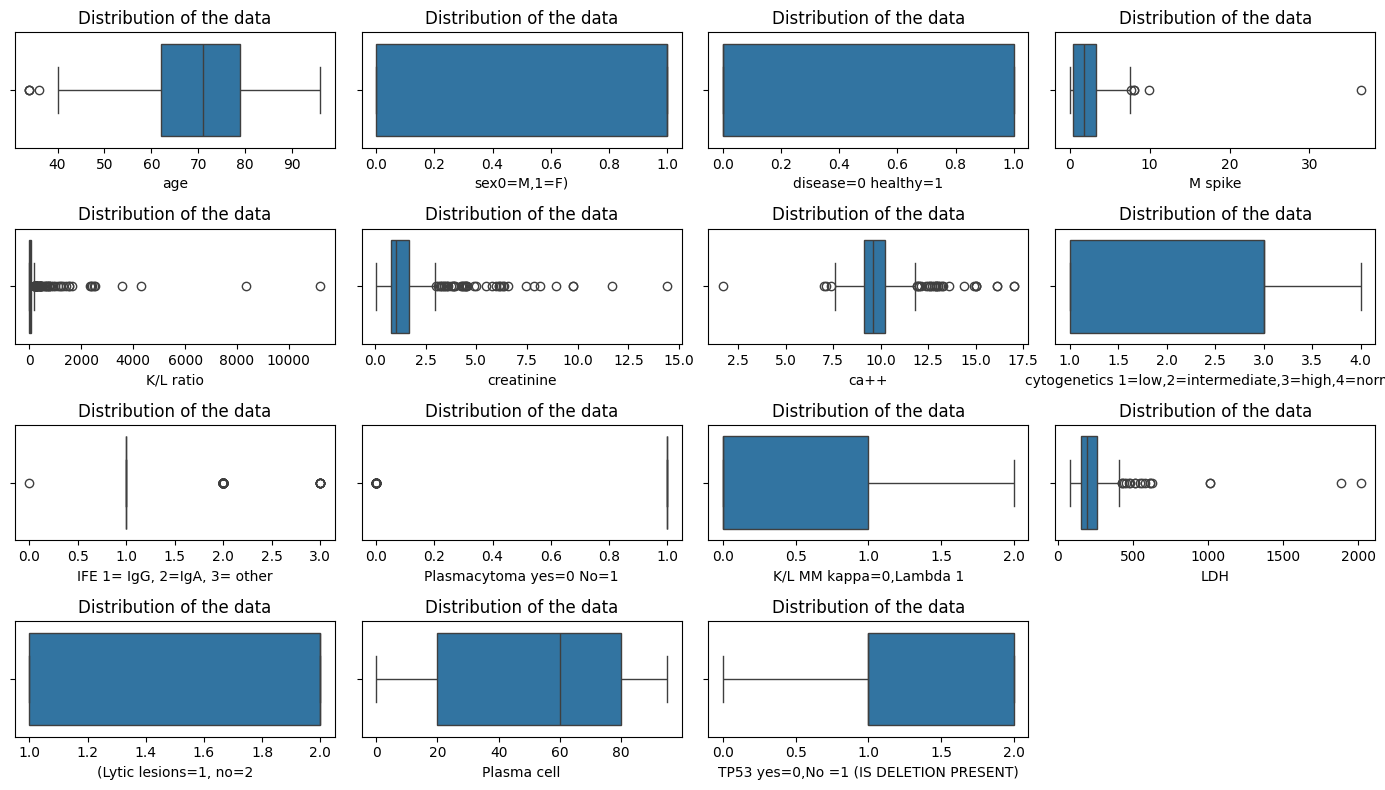

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_column_1st= [
    col for col in df.columns
    if np.issubdtype(df[col].dtype, np.number) and not df[col].isnull().all()]

if len(num_column_1st)==0:
    raise ValueError("No numerical columns to plot")

n_cols_per_row= 4
n_rows= (len(num_column_1st)+n_cols_per_row-1)//n_cols_per_row

fig, axes= plt.subplots(
    nrows= n_rows,
    ncols= n_cols_per_row,
    figsize=(14,8))


axs_flat= np.array(axes).flatten()

for name, ax in zip(num_column_1st, axs_flat):
    sns.boxplot(x=df[name], ax=ax)
    ax.set_title('Distribution of the data')


for i in range(len(num_column_1st), len(axs_flat)):
    fig.delaxes(axs_flat[i])

plt.tight_layout()
plt.show()







**EXPLORE THE DISTRIBUTION OF THROUGH BAR PLOTS**

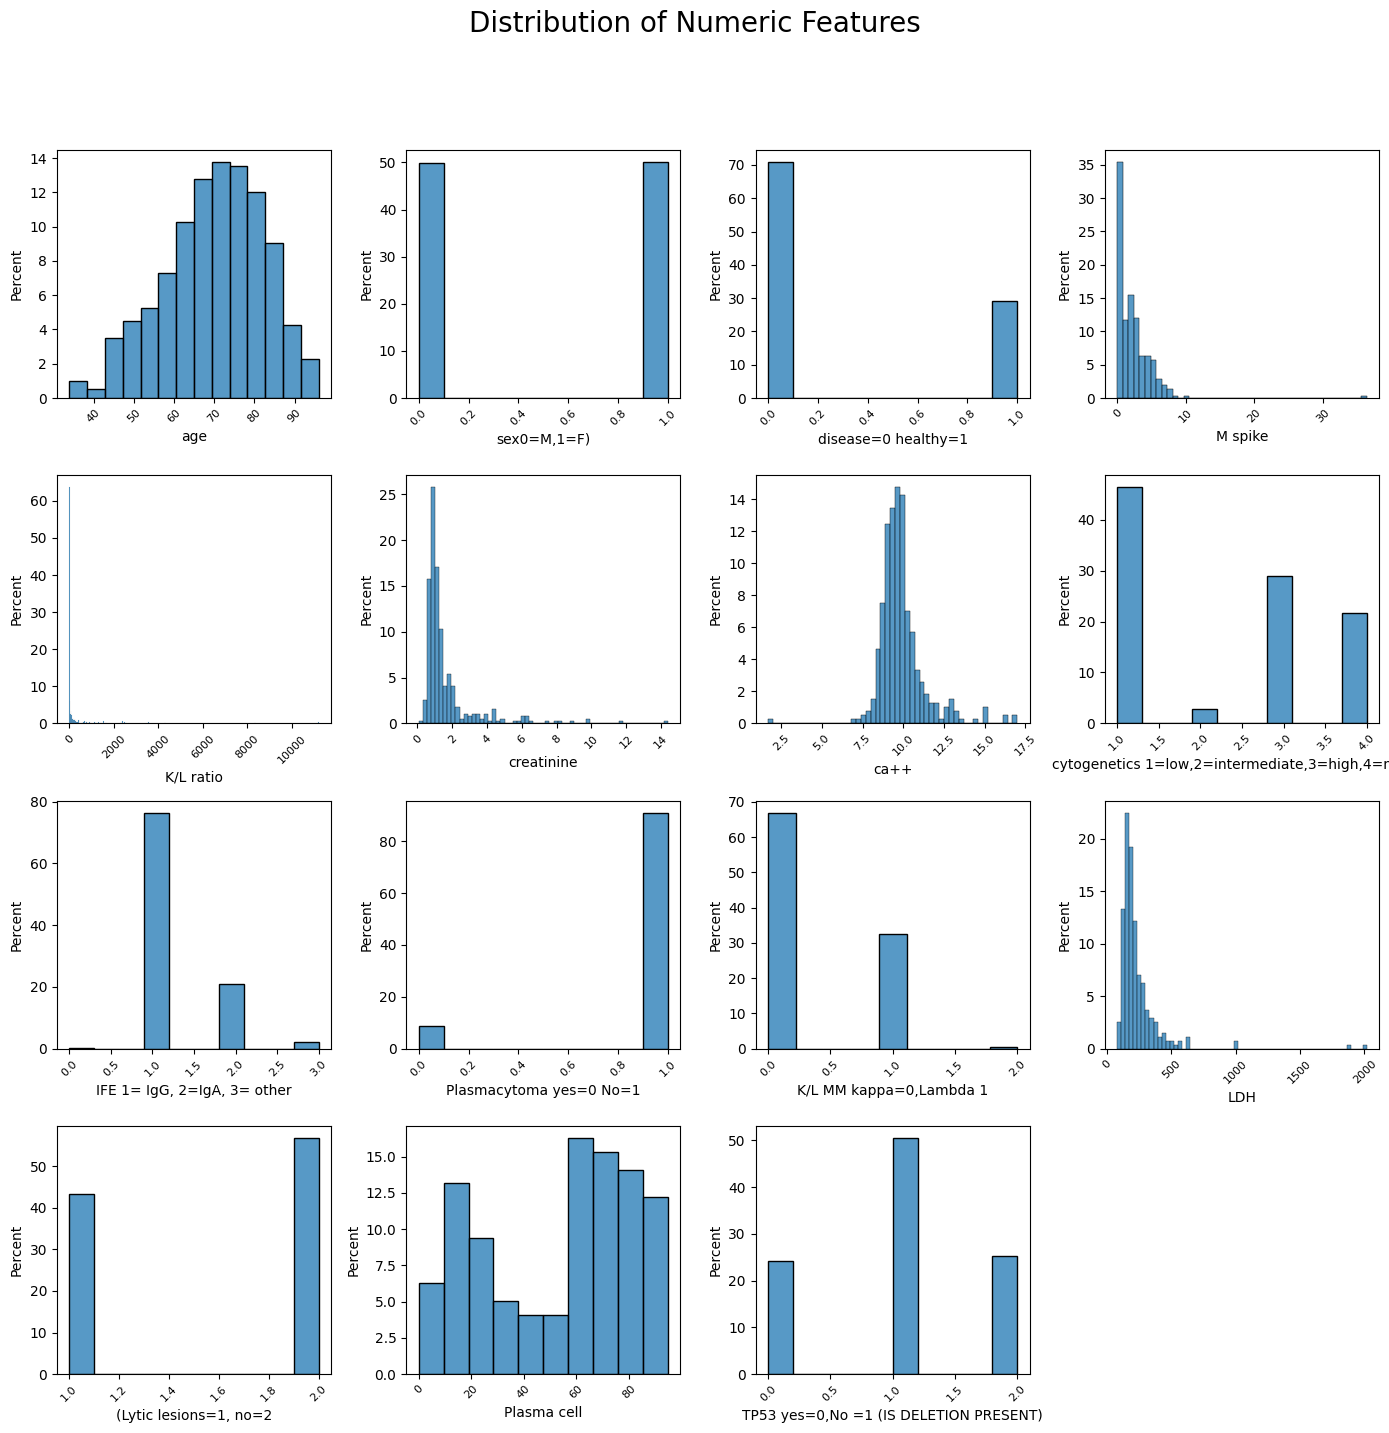

In [6]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 14))

axs_flat = axs.flatten() if axs.ndim > 1 else [axs]

for name, ax in zip(num_column_1st, axs_flat):
    sns.histplot(data=df, x=name, ax=ax, multiple='stack', stat='percent')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# hide unused plots
for ax in axs_flat[len(num_column_1st):]:
    ax.set_visible(False)

fig.suptitle('Distribution of Numeric Features', y=1.02, fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

**CORRELATION MATRIX OF THE NUMERICAL FEATURES**

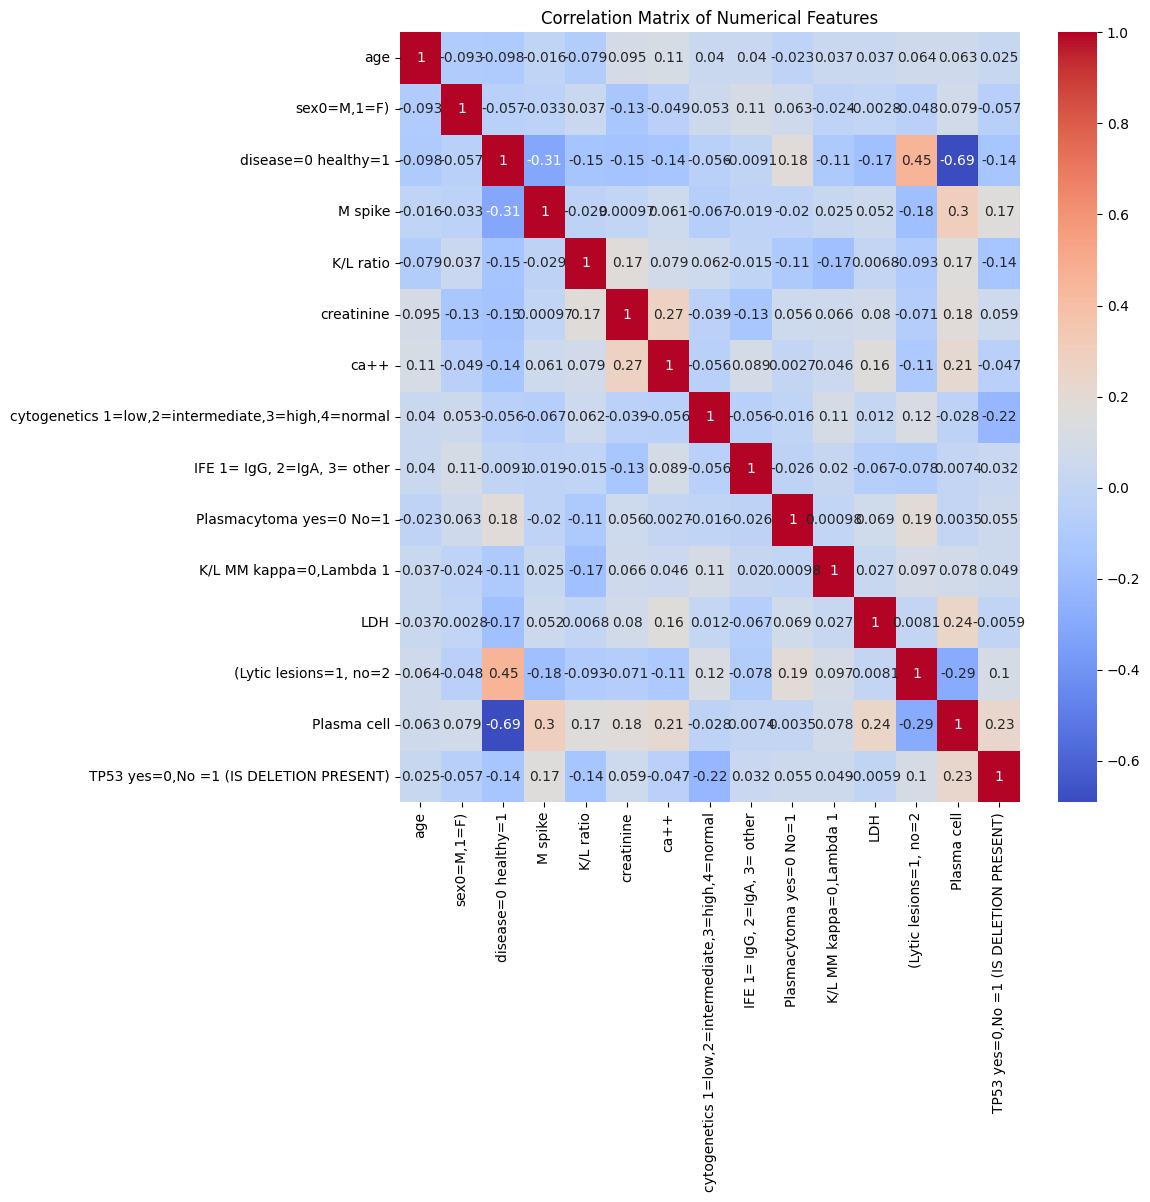

In [7]:
plt.figure(figsize=(10,10))
corr = df[num_column_1st].select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

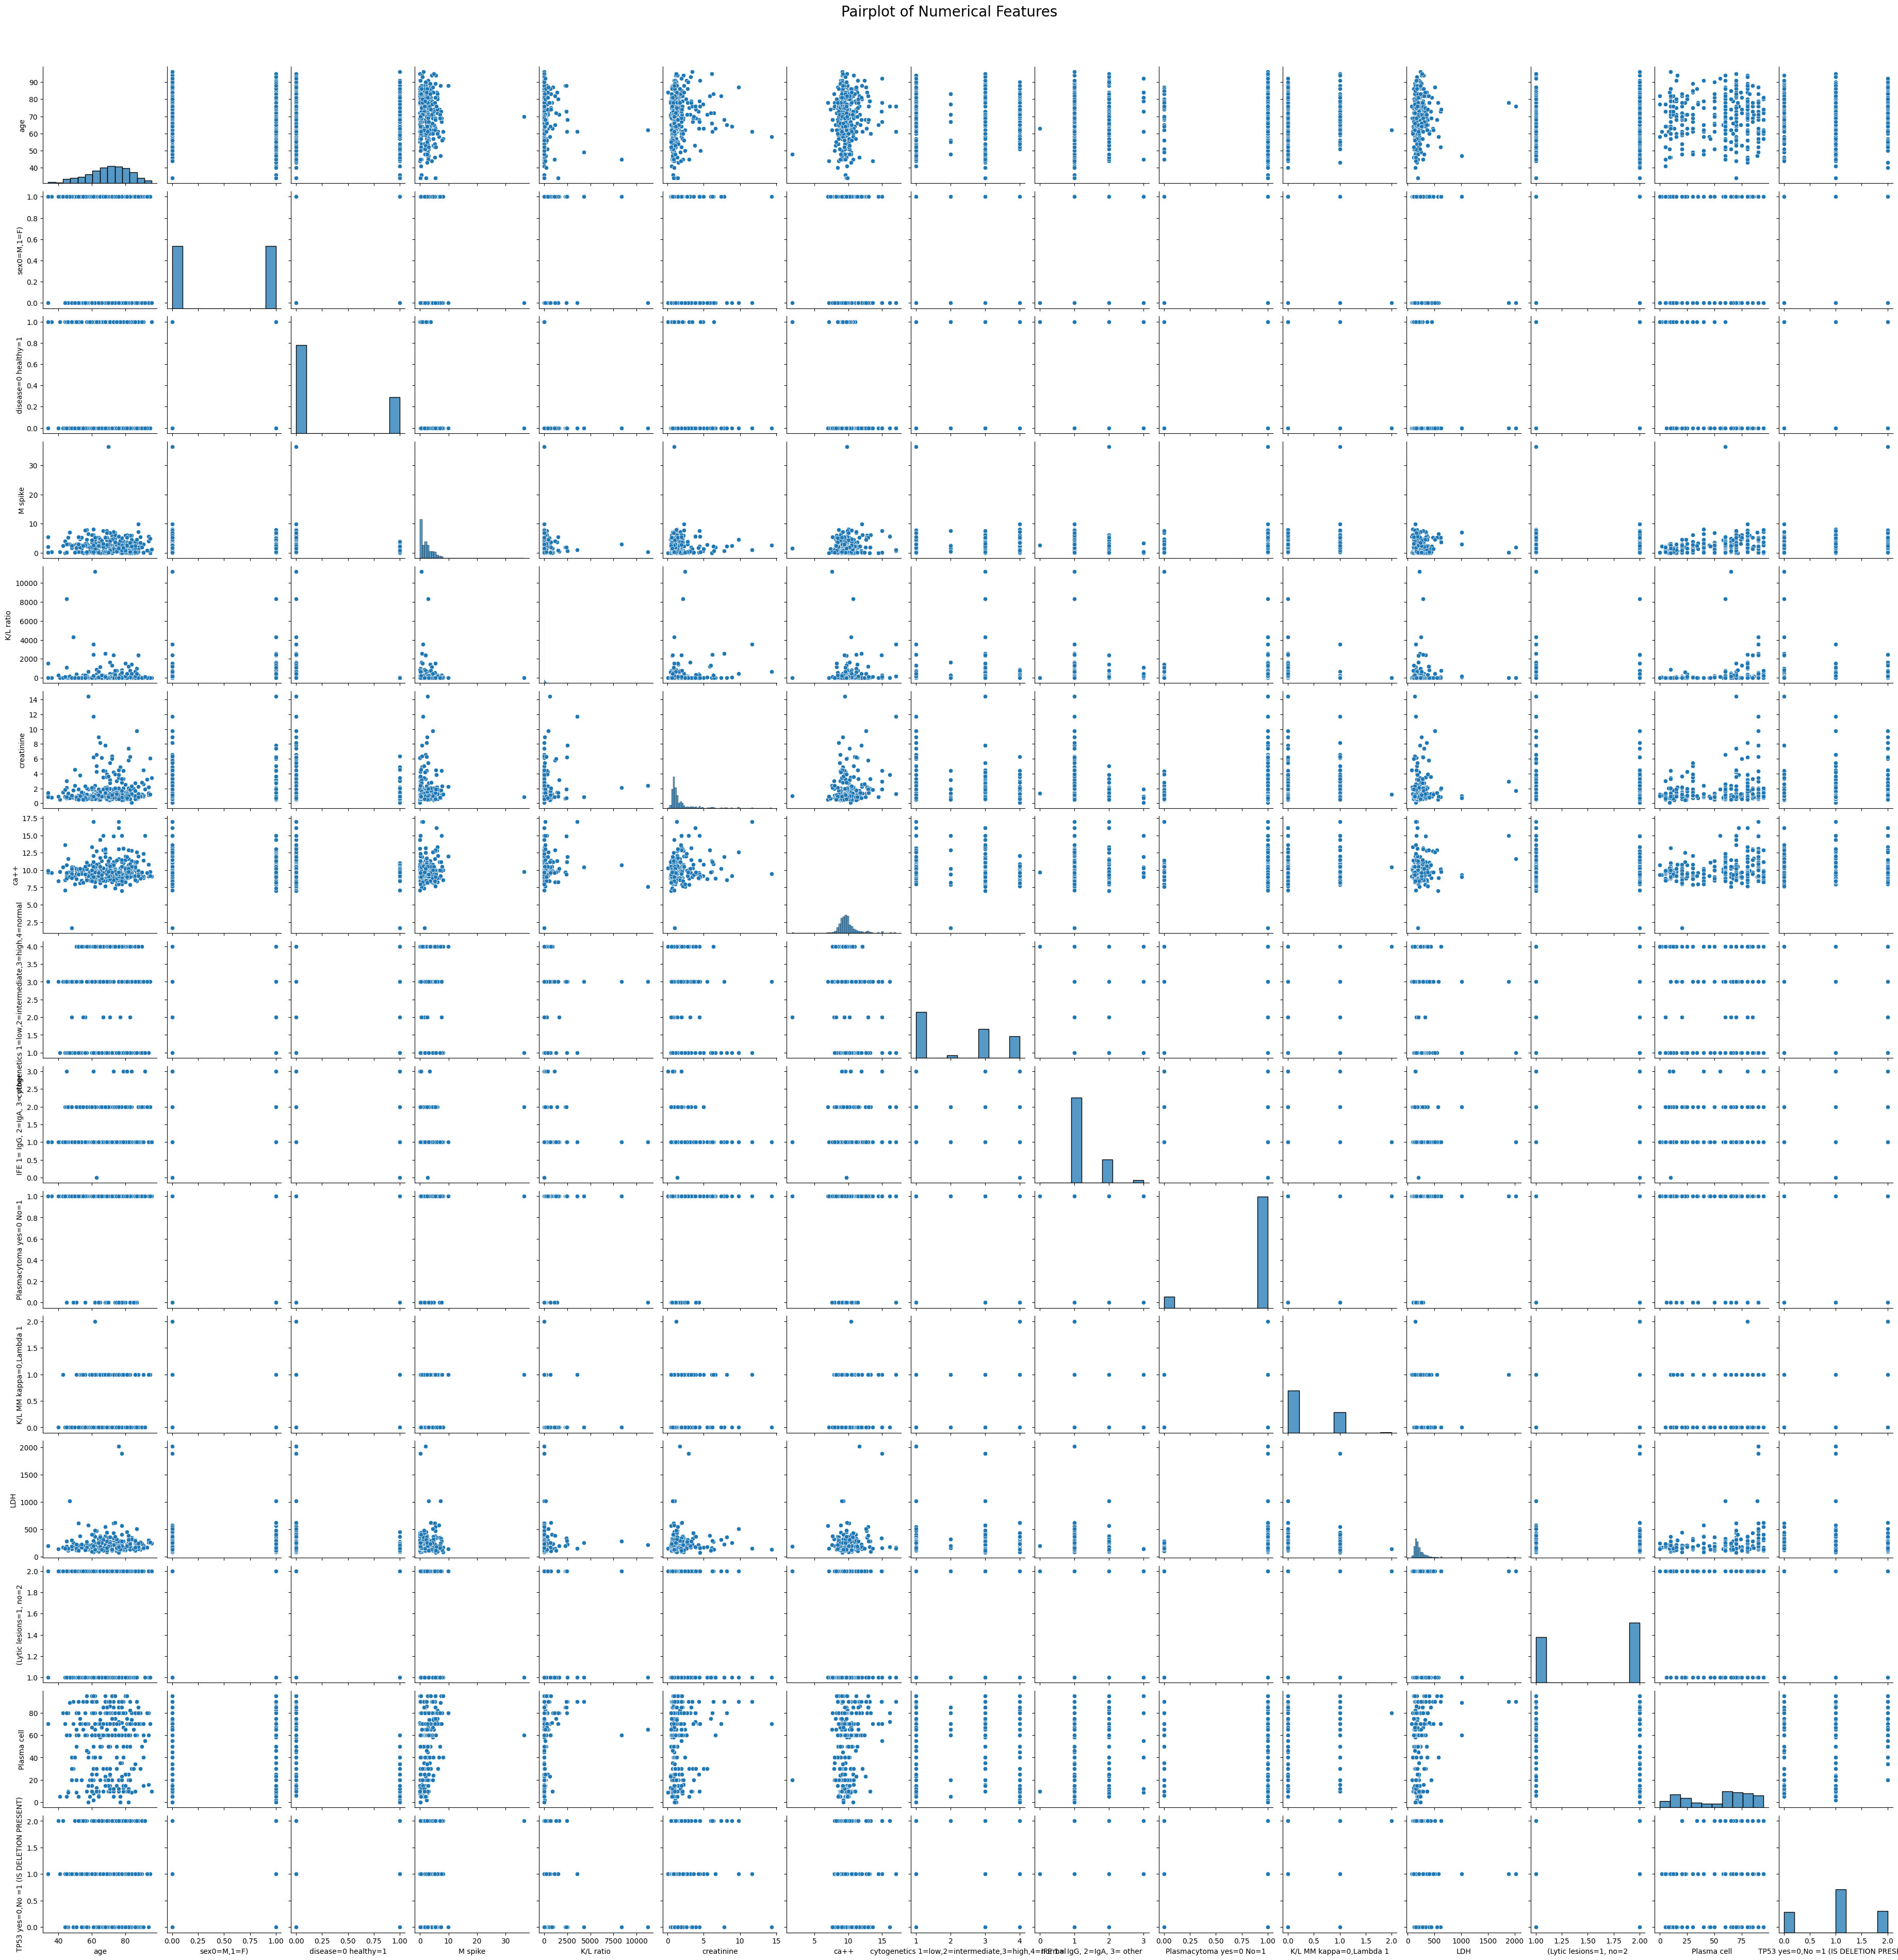

In [8]:
g=sns.pairplot(df[num_column_1st], height= 2.5)

g.fig.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=20)
plt.show()

**CATEGORICAL FEATURES INVESTIGATION**

['B2M', 'Deceased', 'race(1=white 2=Black, 3=Hispanic, 4=other', 'Date of diagnosis', 'Unnamed: 17']


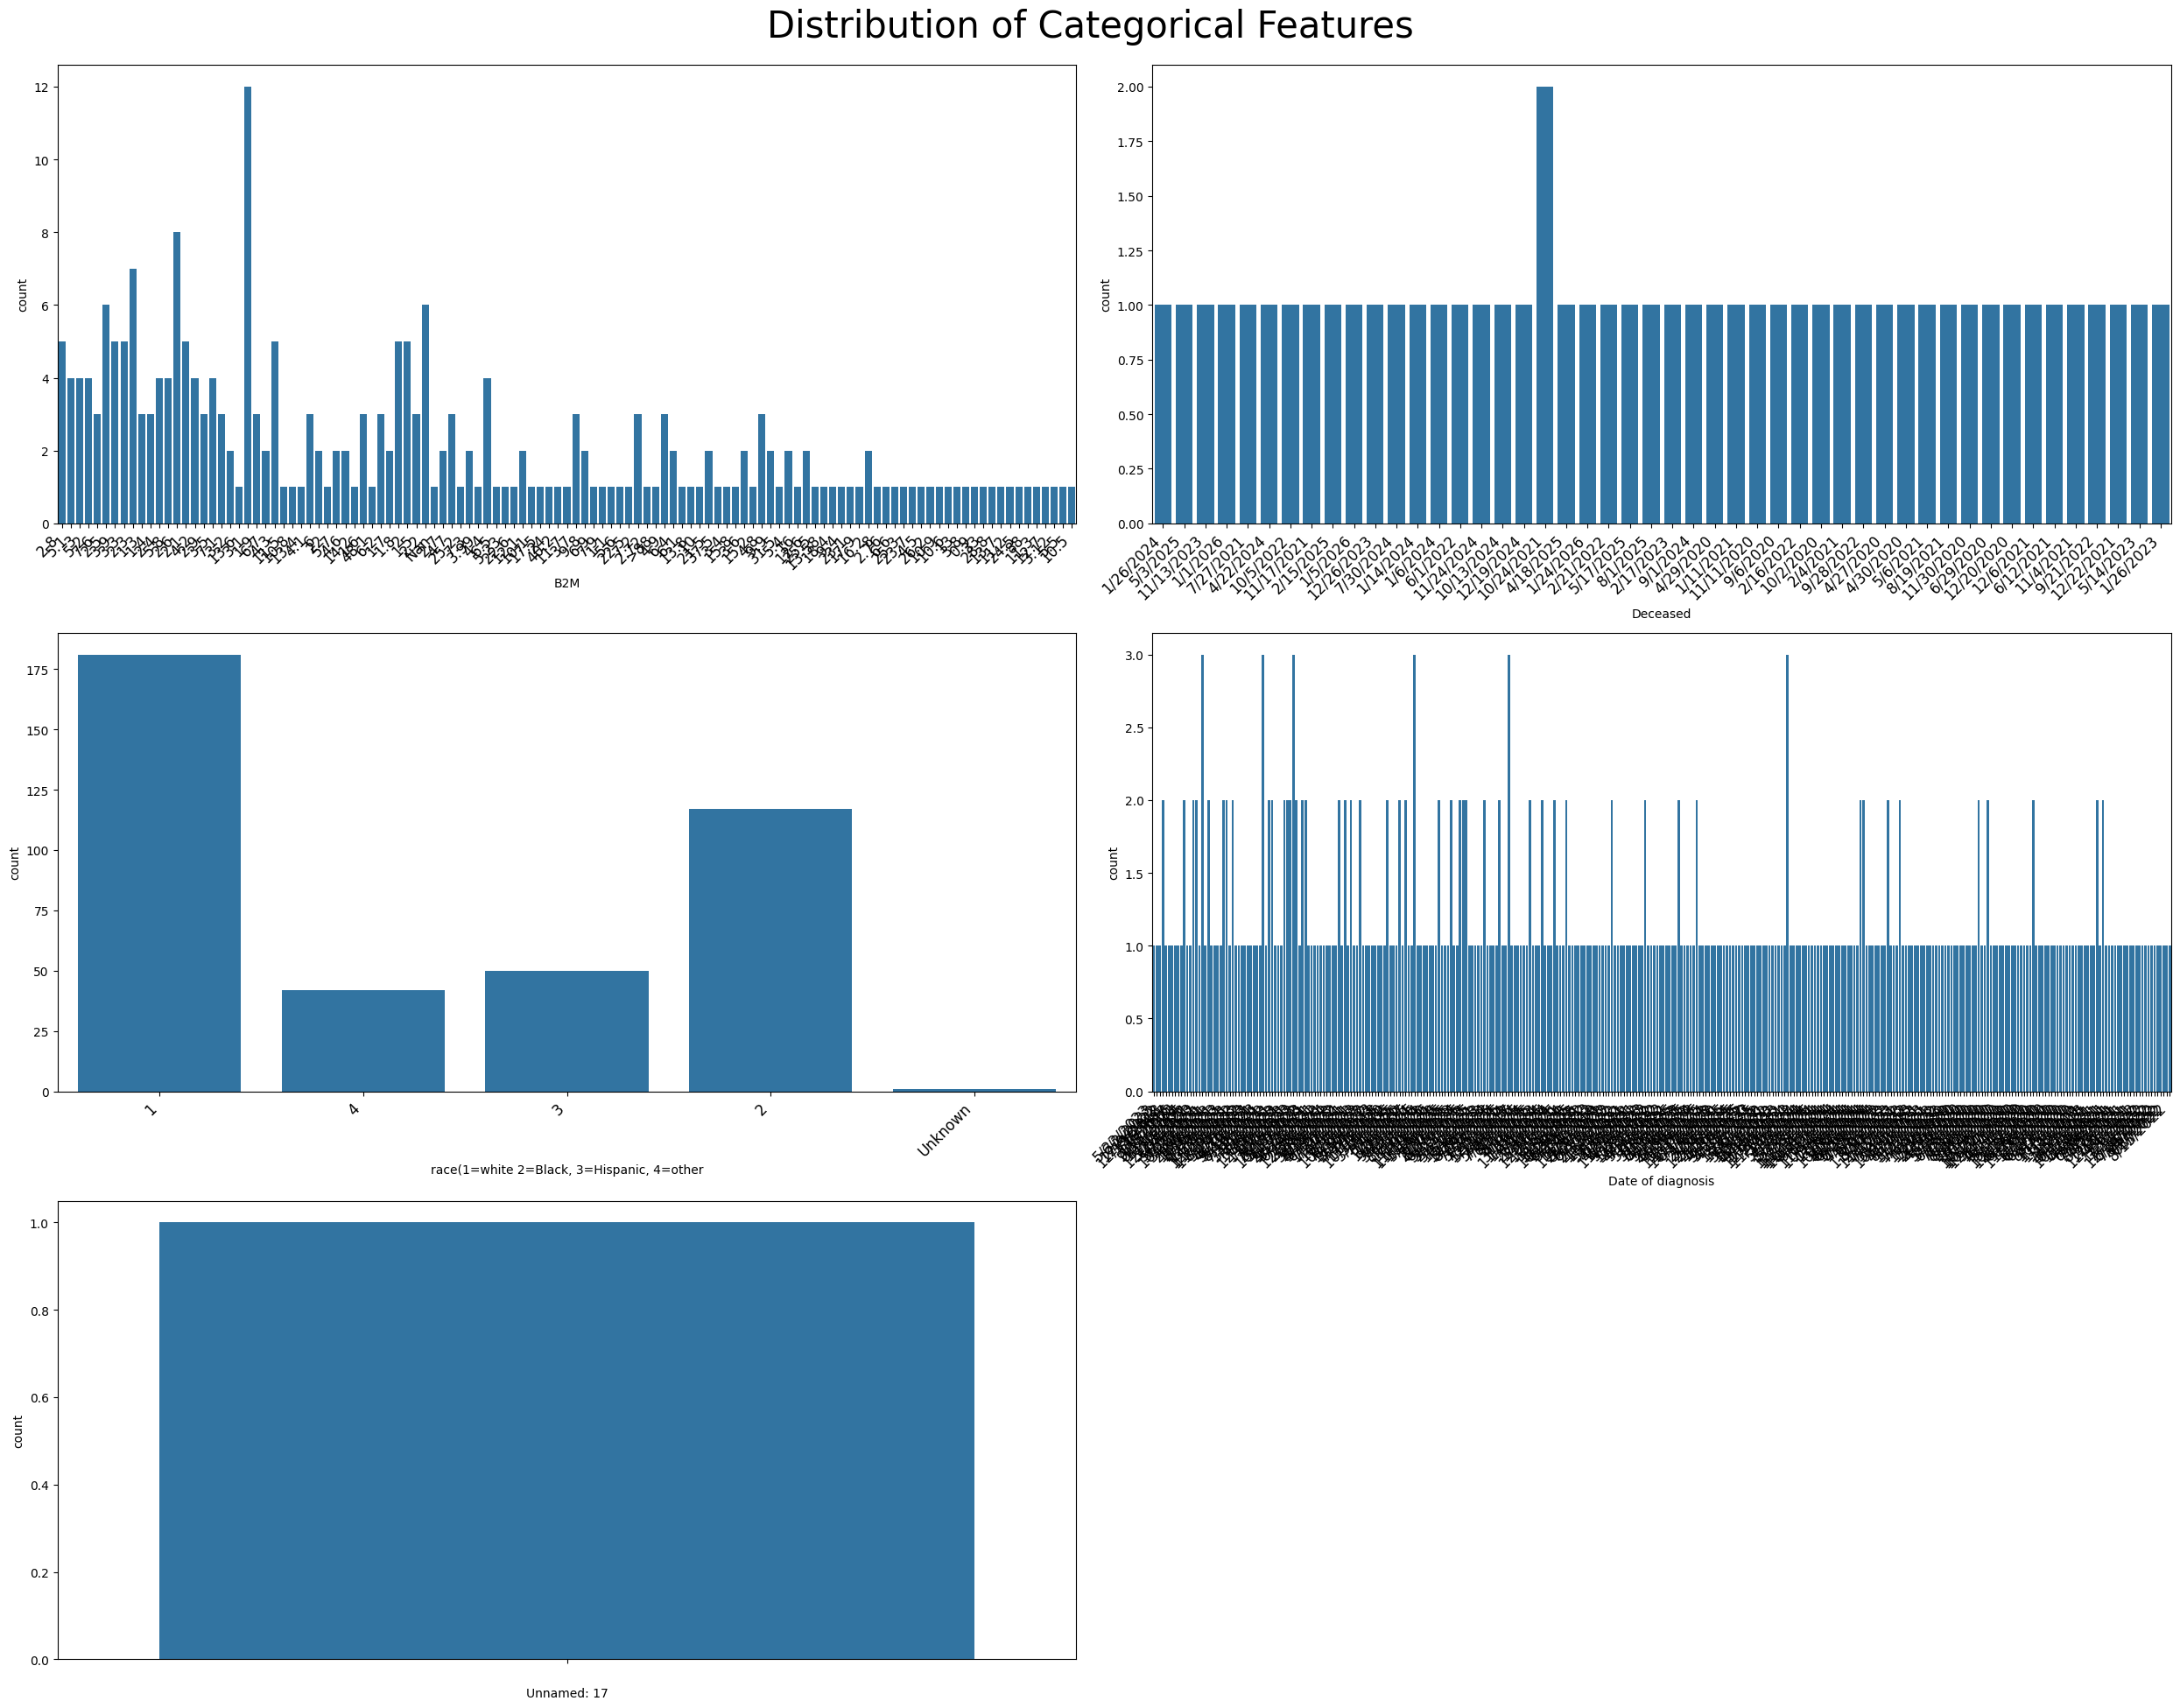

In [9]:
cat_column_1st=[]
for icol in df.columns:
    if df[icol].dtypes in['object']:
        cat_column_1st.append(icol)
print(cat_column_1st)

fig,axs= plt.subplots(nrows=4,ncols=2,figsize=(25,25))
for name,ax in zip(cat_column_1st,axs.flatten()):
    sns.countplot(data=df,x=name,ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right',fontsize=12)

for ax in axs.flatten()[len(cat_column_1st):]:
    ax.set_visible(False)

fig.tight_layout()
fig.suptitle('Distribution of Categorical Features', y=1.02, fontsize=30)
plt.show()

**ENGINIERING FEATURES**

In [10]:
print(df.columns.tolist())

['age', 'sex0=M,1=F)', 'disease=0 healthy=1', 'M spike', 'K/L ratio', 'creatinine', 'ca++', 'B2M', 'Deceased', 'cytogenetics 1=low,2=intermediate,3=high,4=normal', 'race(1=white 2=Black, 3=Hispanic, 4=other', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Date of diagnosis', 'IFE 1= IgG, 2=IgA, 3= other', 'Plasmacytoma yes=0 No=1', 'Unnamed: 17', 'K/L MM kappa=0,Lambda 1', 'LDH', '(Lytic lesions=1, no=2', 'Plasma cell', 'TP53 yes=0,No =1 (IS DELETION PRESENT)']


In [11]:
cols = ['age', 'sex0=M,1=F)',
        'K/L ratio',
        'M spike',
        'cytogenetics 1=low,2=intermediate,3=high,4=normal',
        'TP53 yes=0,No =1 (IS DELETION PRESENT)',
        'disease=0 healthy=1',
        'race(1=white 2=Black, 3=Hispanic, 4=other',
        'Transformed to MM yes 0 no 1']

missing = [col for col in cols if col not in df.columns]
print(" Missing columns:")
print(missing)

 Missing columns:
['Transformed to MM yes 0 no 1']


In [12]:
cols_existing = [col for col in cols if col in df.columns]
DF=df[cols_existing]
print(DF.shape)
DF.head()

(399, 8)


,age,"sex0=M,1=F)",K/L ratio,M spike,"cytogenetics 1=low,2=intermediate,3=high,4=normal","TP53 yes=0,No =1 (IS DELETION PRESENT)",disease=0 healthy=1,"race(1=white 2=Black, 3=Hispanic, 4=other"
0,60,1,4.59,1.6,NaN,1.0,1,1
1,86,0,1.19,0.3,1.0,1.0,1,1
2,55,0,0.02,0.0,NaN,1.0,0,1
3,74,0,14.51,1.7,1.0,1.0,0,4
4,44,1,67.00,4.1,1.0,1.0,0,3


In [13]:
df=df.rename(columns={
'sex0=M,1=F)': 'sex',
'cytogenetics 1=low,2=intermediate,3=high,4=normal': 'cytogenetics',
'TP53 yes=0,No =1 (IS DELETION PRESENT)': 'TP53',
'disease=0 healthy=1': 'disease',
'race(1=white 2=Black, 3=Hispanic, 4=other': 'race',
})

Df=df[['age','sex','K/L ratio','M spike','cytogenetics', 'TP53','disease', 'race']]
print(DF.shape)
DF.head()



(399, 8)


,age,"sex0=M,1=F)",K/L ratio,M spike,"cytogenetics 1=low,2=intermediate,3=high,4=normal","TP53 yes=0,No =1 (IS DELETION PRESENT)",disease=0 healthy=1,"race(1=white 2=Black, 3=Hispanic, 4=other"
0,60,1,4.59,1.6,NaN,1.0,1,1
1,86,0,1.19,0.3,1.0,1.0,1,1
2,55,0,0.02,0.0,NaN,1.0,0,1
3,74,0,14.51,1.7,1.0,1.0,0,4
4,44,1,67.00,4.1,1.0,1.0,0,3


In [14]:
DF=df[['age','sex','K/L ratio', 'M spike','cytogenetics', 'TP53', 'disease', 'race']]

print('Missing values in DF:')
print(DF.isnull().sum())

print('\nData types in DF:')
print(DF.dtypes)


Missing values in DF:
age               0
sex               0
K/L ratio        19
M spike          49
cytogenetics     82
TP53            126
disease           0
race              8
dtype: int64

Data types in DF:
age               int64
sex               int64
K/L ratio       float64
M spike         float64
cytogenetics    float64
TP53            float64
disease           int64
race             object
dtype: object


In [15]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print(DF.columns.tolist())
numerical_impute_scale_cols= ['K/L ratio', 'M spike']
numerical_scale_only_cols= ['age', 'sex']

categorical_impute_ohe_cols= [
    'cytogenetics',
    'TP53'
]
categorical_ohe_only_cols= ['race'] # Removed 'disease' as it's the target variable

all_cols= (
    numerical_impute_scale_cols +
    numerical_scale_only_cols +
    categorical_impute_ohe_cols +
    categorical_ohe_only_cols

)

missing= [col for col in all_cols if col not in DF.columns]
print("Missing columns:", missing)


if len(missing) >0:
    raise ValueError("Some column names do not match DF.columns")

numerical_impute_scale_pipeline= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
numerical_scale_only_pipeline= Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_impute_ohe_pipeline= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
categorical_ohe_only_pipeline= Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))

])
column_transformer= ColumnTransformer(
    transformers=[
        ('num_impute_scale', numerical_impute_scale_pipeline, numerical_impute_scale_cols),
        ('num_scale_only', numerical_scale_only_pipeline, numerical_scale_only_cols),
        ('cat_impute_ohe', categorical_impute_ohe_pipeline, categorical_impute_ohe_cols),
        ('cat_ohe_only', categorical_ohe_only_pipeline, categorical_ohe_only_cols)
    ],
    remainder='drop'
)

['age', 'sex', 'K/L ratio', 'M spike', 'cytogenetics', 'TP53', 'disease', 'race']
Missing columns: []


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Define X and y using the 'disease' column as target
X = DF.drop('disease', axis=1)
y = DF['disease']

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ensure y_train and y_test are of integer type
y_train = y_train.astype(int)
y_test = y_test.astype(int)

X_train_transformed = column_transformer.fit_transform(X_train)
X_test_transformed = column_transformer.transform(X_test)

log_model = LogisticRegression(
    class_weight='balanced',
    solver= 'liblinear',
    max_iter=1000)


log_model.fit(X_train_transformed, y_train)

svm_model= SVC(
    class_weight='balanced',
    probability=True)

svm_model.fit(X_train_transformed, y_train)

custom_weights= {0:1, 1:10}

custom_model = LogisticRegression(
    class_weight=custom_weights,
    solver='liblinear',
    max_iter=1000)


custom_model.fit(X_train_transformed, y_train)

#Predictions
y_pred_log= log_model.predict(X_test_transformed)
y_pred_svm = svm_model.predict(X_test_transformed)
y_pred_custom= custom_model.predict(X_test_transformed)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_log,zero_division=0))

print("SVM Results with Class Weights:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

print("Custom Logistic Regression Results:")
print(classification_report(y_test, y_pred_custom, zero_division=0))






Logistic Regression Results
              precision    recall  f1-score   support

           0       0.91      0.72      0.80        57
           1       0.54      0.83      0.66        23

    accuracy                           0.75        80
   macro avg       0.73      0.77      0.73        80
weighted avg       0.81      0.75      0.76        80

SVM Results with Class Weights:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82        57
           1       0.57      0.91      0.70        23

    accuracy                           0.78        80
   macro avg       0.76      0.82      0.76        80
weighted avg       0.84      0.78      0.79        80

Custom Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.96      0.42      0.59        57
           1       0.40      0.96      0.56        23

    accuracy                           0.57        80
   macro avg       0.68      0.6

**LOGISTIC REGRESSION**

Fit Time     0.0 seconds
Accuracy            0.75
ROC_AUC         0.887109
F1              0.655172
Precision       0.542857
Recall          0.826087
Name: Logistic Regression, dtype: object


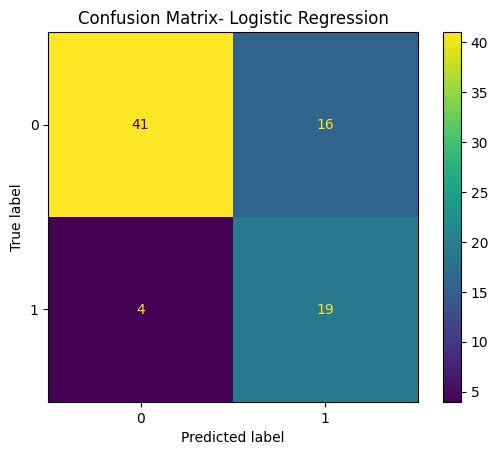

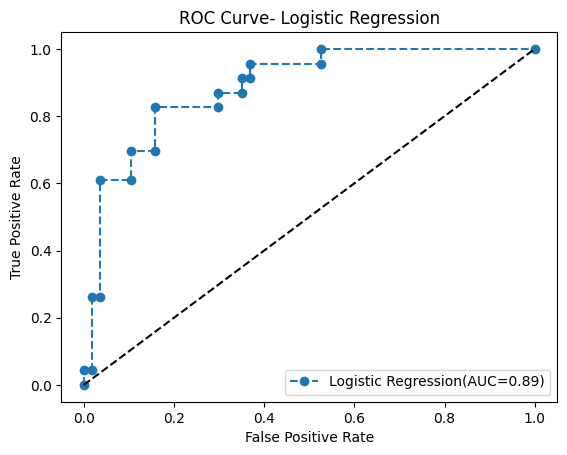

In [17]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,precision_score,recall_score,roc_auc_score,ConfusionMatrixDisplay, roc_curve)
from sklearn.model_selection import train_test_split
import pandas as pd
import time

#Fit transformer on training data only
X_train_transformed_local = column_transformer.fit_transform(X_train)
X_test_transformed_local = column_transformer.transform(X_test)

logreg= LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=1000)

start= time.time()
logreg.fit(X_train_transformed_local, y_train)
stop= time.time()

fit_time= str(round(stop-start,2)) + ' seconds'

y_pred= logreg.predict(X_test_transformed_local)
y_pred_proba= logreg.predict_proba(X_test_transformed_local)[:,1]

results_df= pd.DataFrame(
    columns=('Fit Time', 'Accuracy','ROC_AUC', 'F1', 'Precision','Recall'))

results_df.loc['Logistic Regression', 'Fit Time'] = fit_time
results_df.loc['Logistic Regression', 'Accuracy'] = accuracy_score(y_test, y_pred)
results_df.loc['Logistic Regression', 'ROC_AUC'] = roc_auc_score(y_test, y_pred_proba)
results_df.loc['Logistic Regression', 'F1'] = f1_score(y_test, y_pred, zero_division=0)
results_df.loc['Logistic Regression', 'Precision'] = precision_score(y_test, y_pred, zero_division=0)
results_df.loc['Logistic Regression', 'Recall'] = recall_score(y_test, y_pred, zero_division=0)


print(results_df.loc['Logistic Regression'])

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix- Logistic Regression')
plt.show()

fpr,tpr,thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr,'--o', label= f"Logistic Regression(AUC={results_df.loc['Logistic Regression', 'ROC_AUC']:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- Logistic Regression')
plt.legend()
plt.show()

**K-Nearest Neighbors **

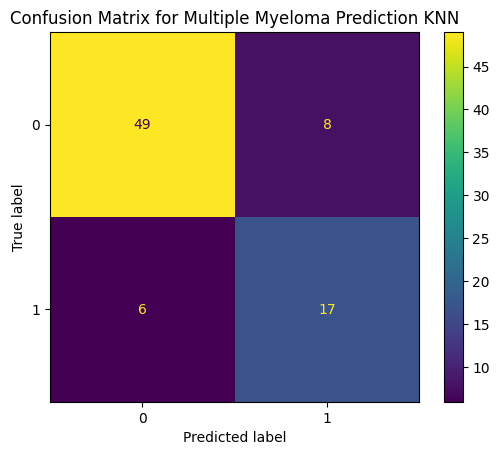

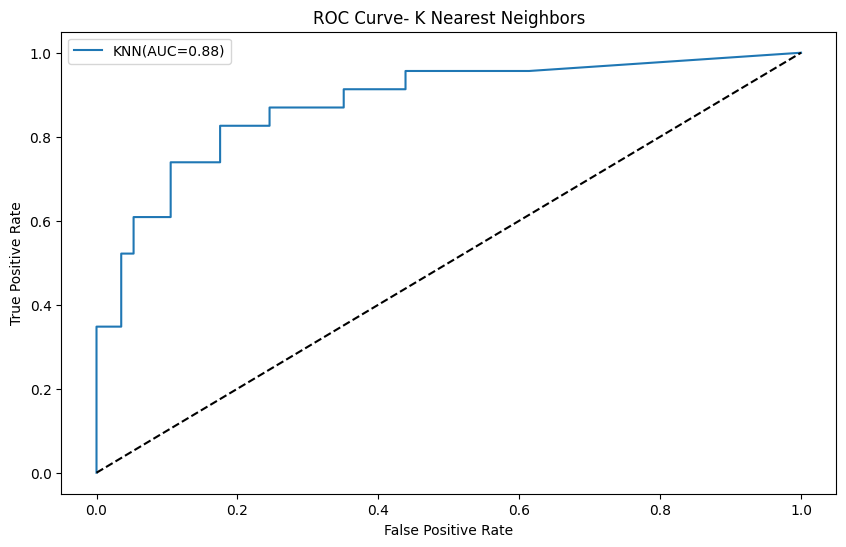

Fit Time     0.0 seconds
Accuracy           0.825
ROC_AUC         0.880244
F1              0.708333
Precision           0.68
Recall           0.73913
Name: KNN, dtype: object


In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, roc_curve)

import pandas as pd
import matplotlib.pyplot as plt
import time


knn= KNeighborsClassifier(n_neighbors=5, weights='distance')
start= time.time()
knn.fit(X_train_transformed_local, y_train)
stop= time.time()

fit_time= str(round(stop-start,2)) + ' seconds'

y_pred_knn= knn.predict(X_test_transformed_local)
y_proba_knn= knn.predict_proba(X_test_transformed_local)


ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=knn.classes_)
plt.title("Confusion Matrix for Multiple Myeloma Prediction KNN")
plt.show()


results_df= pd.DataFrame(
    columns=['Fit Time', 'Accuracy','ROC_AUC', 'F1', 'Precision','Recall'])


results_df.loc['KNN', 'Fit Time'] = fit_time
results_df.loc['KNN', 'Accuracy'] = accuracy_score(y_test, y_pred_knn)
results_df.loc['KNN', 'F1'] = f1_score(y_test, y_pred_knn, zero_division=0)
results_df.loc['KNN', 'Precision'] = precision_score(y_test, y_pred_knn, zero_division=0)
results_df.loc['KNN', 'Recall']= recall_score(y_test, y_pred_knn, zero_division=0)


if len(knn.classes_)==2:
   positive_class_index= list(knn.classes_).index(1)
   y_score_knn= y_proba_knn[:,positive_class_index]

   results_df.loc['KNN', 'ROC_AUC'] = roc_auc_score(y_test, y_score_knn)


   fpr,tpr,thresholds = roc_curve(y_test, y_score_knn)

   plt.figure(figsize=(10,6))
   plt.plot(fpr, tpr, label= f"KNN(AUC={results_df.loc['KNN', 'ROC_AUC']:.2f})")
   plt.plot([0,1],[0,1], 'k--')
   plt.xlabel('False Positive Rate')
   plt.ylabel('True Positive Rate')
   plt.title('ROC Curve- K Nearest Neighbors')
   plt.legend()
   plt.show()

else:
    results_df.loc['KNN', 'ROC_AUC'] = None
    print("ROC AUC skipped because only one class is present.")
print(results_df.loc['KNN'])

**SUPPORT VECTOR CLASSIFICATION**

Fit Time     0.04 seconds
Accuracy            0.775
ROC_AUC           0.90389
F1                   0.82
Precision        0.953488
Recall           0.719298
Name: SVM, dtype: object


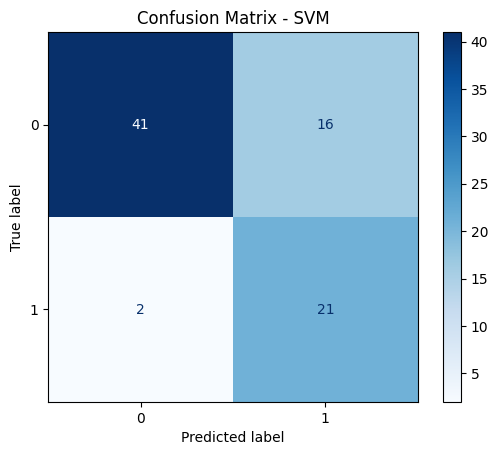

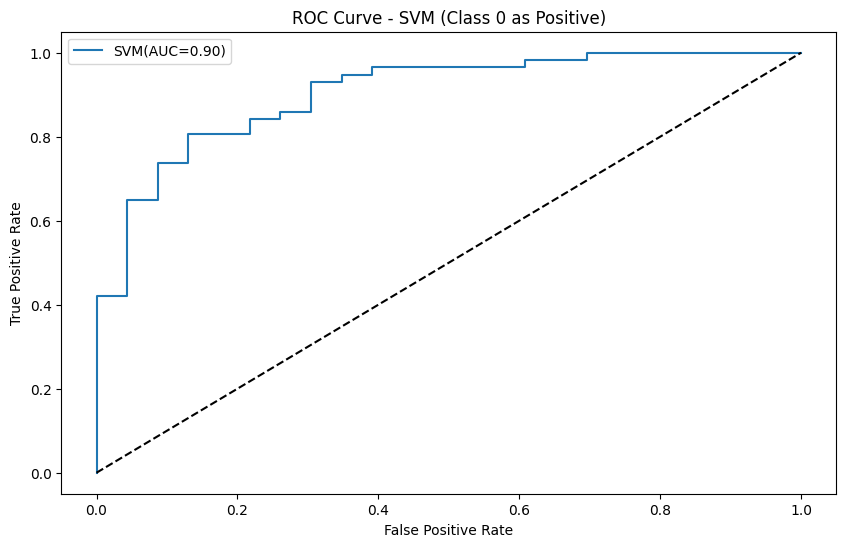

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve)

# Ensure the SVM model is defined and fitted
# These variables (X_train_transformed_local, y_train, X_test_transformed_local, y_test)
# are assumed to be available from previous execution in the notebook.
svm_model = SVC(class_weight='balanced', probability=True)
start = time.time()
svm_model.fit(X_train_transformed_local, y_train)
stop = time.time()

fit_time = str(round(stop - start, 2)) + ' seconds'

y_pred_svm = svm_model.predict(X_test_transformed_local)
y_proba_svm = svm_model.predict_proba(X_test_transformed_local)

# The results_df currently in the kernel might only have KNN data.
# This code will add a new row for SVM, extending the existing DataFrame.
# Ensure 'Fit Time' column exists as it is used here.
if 'Fit Time' not in results_df.columns:
    results_df['Fit Time'] = None

results_df.loc['SVM', 'Fit Time'] = fit_time
results_df.loc['SVM', 'Accuracy'] = accuracy_score(y_test, y_pred_svm)

# Assuming class 0 is the positive class of interest (Multiple Myeloma) based on pos_label=0 in F1, Precision, Recall
# For ROC_AUC, convert y_test such that the positive class (0) becomes 1.
# And use probabilities for this "new" positive class, which is y_proba_svm[:, 0].
results_df.loc['SVM', 'ROC_AUC'] = roc_auc_score((y_test == 0).astype(int), y_proba_svm[:, 0])

results_df.loc['SVM', 'F1'] = f1_score(y_test, y_pred_svm, pos_label=0, zero_division=0)
results_df.loc['SVM', 'Precision'] = precision_score(y_test, y_pred_svm, pos_label=0, zero_division=0)
results_df.loc['SVM', 'Recall'] = recall_score(y_test, y_pred_svm, pos_label=0, zero_division=0)

print(results_df.loc['SVM'])

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, display_labels=svm_model.classes_, cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.show()

# ROC Curve for class 0 (MM)
# y_true needs to be binary with positive class as 1 for roc_curve
# y_score needs to be probability of positive class
fpr, tpr, thresholds = roc_curve(
    (y_test == 0).astype(int),  # y_true: where original class 0 (MM) is now 1
    y_proba_svm[:, 0],          # y_score: probability of original class 0 (MM)
    pos_label=1                 # Explicitly state that the positive label in (y_test == 0).astype(int) is 1
)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"SVM(AUC={results_df.loc['SVM', 'ROC_AUC']:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM (Class 0 as Positive)')
plt.legend()
plt.show()


**DECISION TREE CLASSIFIER**

Accuracy       0.8125
ROC_AUC      0.803585
F1           0.862385
Precision    0.903846
Recall       0.824561
Name: Decision Tree, dtype: object


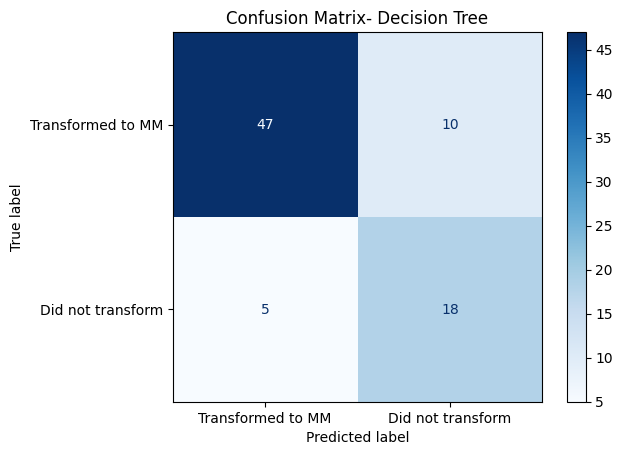

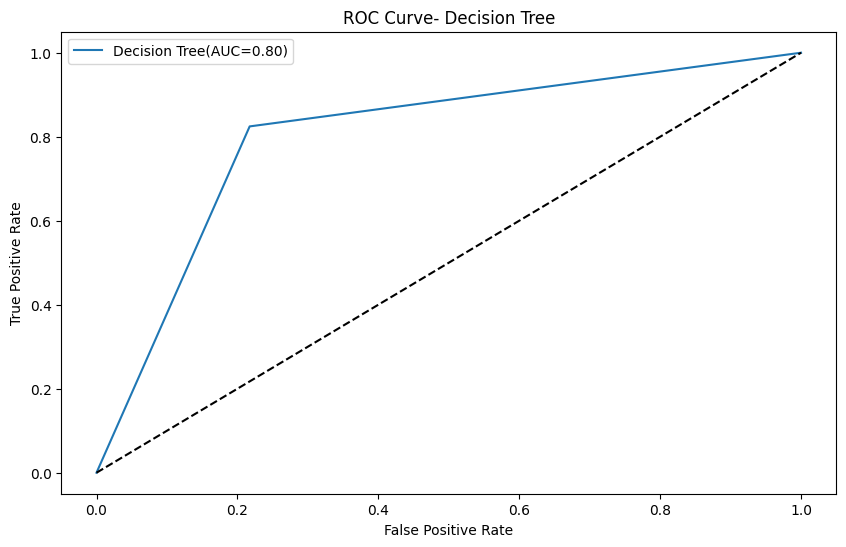

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve)
import pandas as pd
import matplotlib.pyplot as plt
import time

results_df= pd.DataFrame(columns=('Accuracy','ROC_AUC','F1','Precision','Recall'))
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train_transformed_local, y_train)


y_pred= dt_model.predict(X_test_transformed_local)
y_proba= dt_model.predict_proba(X_test_transformed_local)

y_proba_transform= y_proba[:,0]

results_df.loc['Decision Tree', 'Accuracy'] = accuracy_score(y_test, y_pred)

results_df.loc['Decision Tree', 'ROC_AUC'] = roc_auc_score(
    (y_test==0).astype(int),
     y_proba_transform)

results_df.loc['Decision Tree', 'F1'] = f1_score(y_test, y_pred, pos_label=0)
results_df.loc['Decision Tree', 'Precision'] = precision_score(y_test, y_pred, pos_label=0)
results_df.loc['Decision Tree', 'Recall'] = recall_score(y_test, y_pred,pos_label=0)

print(results_df.loc['Decision Tree'])

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Transformed to MM', 'Did not transform'],
    cmap='Blues'
)

plt.title('Confusion Matrix- Decision Tree')
plt.show()

fpr,tpr,thresholds = roc_curve(
    (y_test==0).astype(int),
    y_proba_transform)

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, label= f"Decision Tree(AUC={results_df.loc['Decision Tree', 'ROC_AUC']:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- Decision Tree')
plt.legend()
plt.show()

**RANDOM FOREST CLASSIFIER**

Accuracy       0.8375
ROC_AUC      0.917239
F1           0.711111
Precision    0.727273
Recall       0.695652
Name: random forest, dtype: object


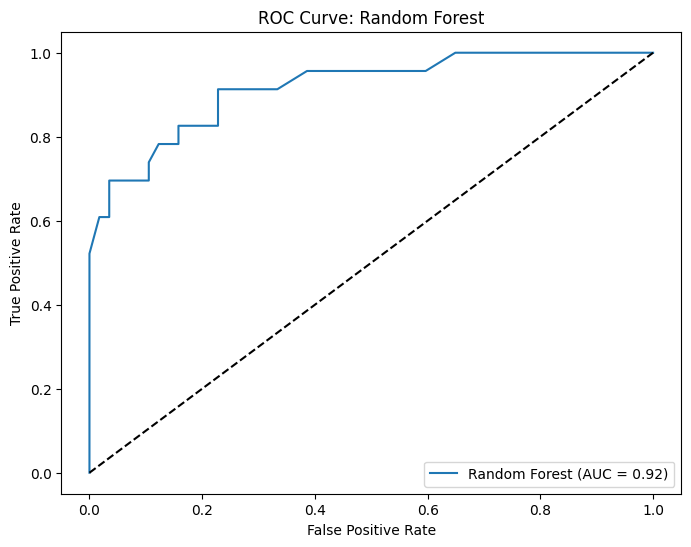

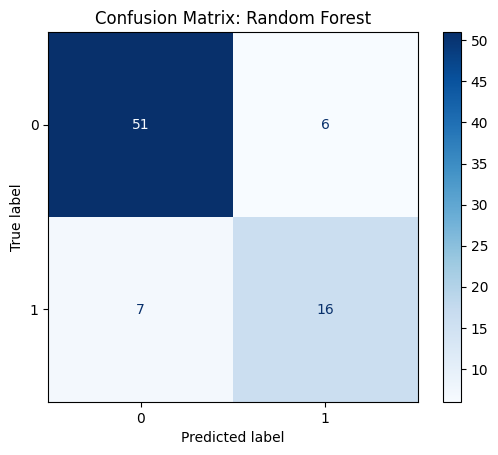

              Accuracy   ROC_AUC        F1 Precision    Recall
Decision Tree   0.8125  0.803585  0.862385  0.903846  0.824561
random forest   0.8375  0.917239  0.711111  0.727273  0.695652


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay)

# Assuming results_df is initialized earlier in the notebook, if not, it should be re-initialized.
# Based on the previous execution, results_df should already be a DataFrame.
# If this is the first model in a fresh run, then results_df needs to be defined.
# For now, assuming results_df is already defined from a previous cell.
# If results_df is not defined before this cell, uncomment the next line:
# results_df = pd.DataFrame(columns=('Accuracy', 'ROC_AUC', 'F1', 'Precision', 'Recall'))

rf_model= RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
rf_model.fit(X_train_transformed_local, y_train)

y_pred= rf_model.predict(X_test_transformed_local)
y_proba= rf_model.predict_proba(X_test_transformed_local)[:,1]

# Ensure results_df is properly initialized to avoid potential KeyError if this is the first model run in a fresh kernel
if 'random forest' not in results_df.index:
    results_df.loc['random forest', :] = None # Initialize the row if it doesn't exist

results_df.loc['random forest', 'Accuracy'] = accuracy_score(y_test,y_pred)
results_df.loc['random forest', 'ROC_AUC'] = roc_auc_score(y_test, y_proba)
results_df.loc['random forest', 'F1'] = f1_score(y_test,y_pred)
results_df.loc['random forest', 'Precision'] = precision_score(y_test,y_pred, zero_division=0)
results_df.loc['random forest', 'Recall'] = recall_score(y_test,y_pred)

print(results_df.loc['random forest'])

fpr,tpr,thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8,6)) # Corrected: figsize should be a tuple

plt.plot(fpr,tpr, label= f"Random Forest (AUC = {results_df.loc['random forest', 'ROC_AUC']:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Random Forest')
plt.legend(loc='lower right')
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=rf_model.classes_, cmap='Blues')
plt.title('Confusion Matrix: Random Forest')
plt.show()

print(results_df)

**EXTREME GRADIENT BOOSTING**

Accuracy          0.8
ROC_AUC      0.906941
F1           0.703704
Precision    0.612903
Recall       0.826087
Name: XGBoost, dtype: object


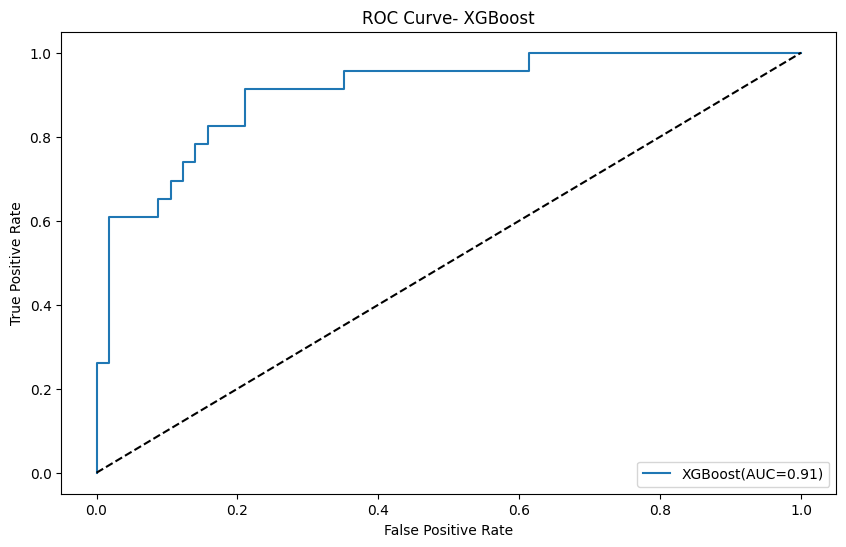

Accuracy          0.8
ROC_AUC      0.906941
F1           0.703704
Precision    0.612903
Recall       0.826087
Name: XGBoost, dtype: object


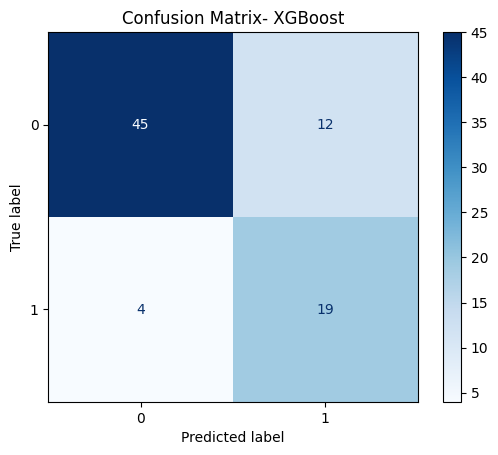

        Accuracy   ROC_AUC        F1 Precision    Recall
XGBoost      0.8  0.906941  0.703704  0.612903  0.826087


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,precision_score, recall_score, ConfusionMatrixDisplay, roc_curve)

negative_count= (y_train==0).sum()
positive_count = (y_train==1).sum()

scale_pos_weight = negative_count / positive_count

results_df= pd.DataFrame(columns=('Accuracy','ROC_AUC','F1','Precision','Recall'))

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric= 'logloss'
)

xgb_model.fit(X_train_transformed_local, y_train)

y_pred= xgb_model.predict(X_test_transformed_local)
y_proba= xgb_model.predict_proba(X_test_transformed_local)[:,1]

results_df.loc['XGBoost', 'Accuracy'] = accuracy_score(y_test, y_pred)
results_df.loc['XGBoost', 'ROC_AUC'] = roc_auc_score(y_test, y_proba)
results_df.loc['XGBoost', 'F1'] = f1_score(y_test, y_pred)
results_df.loc['XGBoost', 'Precision'] = precision_score(y_test, y_pred, zero_division=0)
results_df.loc['XGBoost', 'Recall'] = recall_score(y_test, y_pred)

print(results_df.loc['XGBoost'])

fpr,tpr,thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(10,6))
plt.plot(fpr, tpr,label= f"XGBoost(AUC={results_df.loc['XGBoost', 'ROC_AUC']:.2f})")

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- XGBoost')
plt.legend(loc='lower right')
plt.show()

print(results_df.loc['XGBoost'])

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=xgb_model.classes_, cmap='Blues')
plt.title('Confusion Matrix- XGBoost')
plt.show()

print(results_df)


**IMPROVING THE MODEL**-
**Logistic Regression & GridSearch**

Best Parameters: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1'}
Best Score: 0.8800025425883549
              precision    recall  f1-score   support

           0       0.91      0.74      0.82        57
           1       0.56      0.83      0.67        23

    accuracy                           0.76        80
   macro avg       0.74      0.78      0.74        80
weighted avg       0.81      0.76      0.77        80

ROC AUC Score for Logistic Regression= 0.872


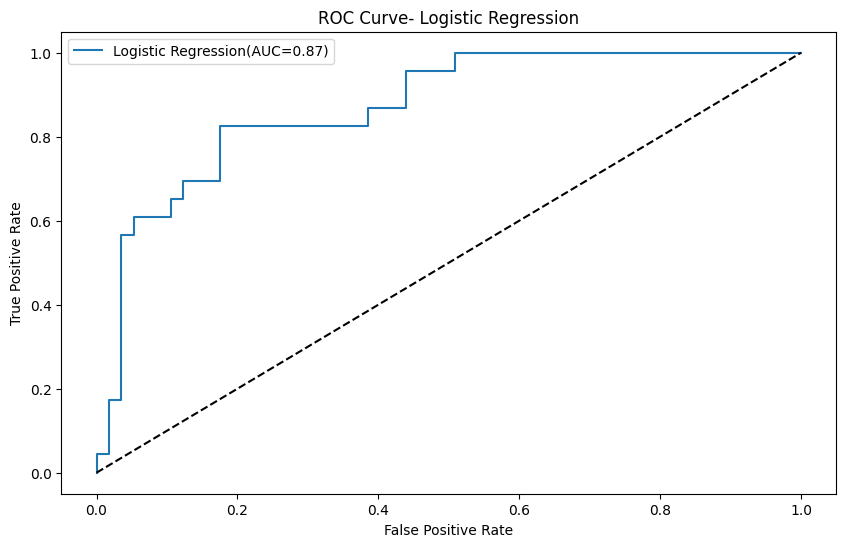

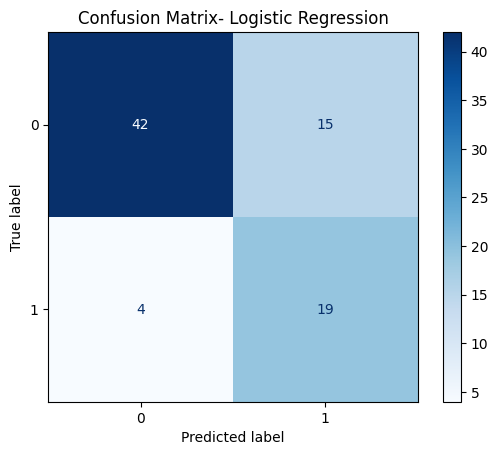

Accuracy           0.7625
ROC_AUC          0.781465
F1               0.666667
Precision        0.558824
Recall           0.826087
Fit Time     4.04 seconds
Name: GridSearch Logistic Regression, dtype: object


In [21]:
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Define the pipeline for Logistic Regression
lgr_pipe = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Define the parameters for GridSearchCV
lgr_params = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

lgr_grid= GridSearchCV(
    lgr_pipe,
    param_grid=lgr_params,
    cv=5,
    scoring='roc_auc'
)

start= time.time()
lgr_grid.fit(X_train, y_train)
stop= time.time()

fit_time= str(round(stop-start,2)) + ' seconds'

print(f"Best Parameters: {lgr_grid.best_params_}")
print(f"Best Score: {lgr_grid.best_score_}")

#Predictions
y_pred= lgr_grid.predict(X_test)
y_probs= lgr_grid.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, zero_division=0))

lgr_roc_score= roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score for Logistic Regression= {lgr_roc_score:.3f}")

fpr,tpr,thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, label= f"Logistic Regression(AUC={lgr_roc_score:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- Logistic Regression')
plt.legend()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix- Logistic Regression')
plt.show()

# Ensure results_df is properly initialized if not already done in the current scope
if 'GridSearch Logistic Regression' not in results_df.index:
    results_df.loc['GridSearch Logistic Regression', :] = None

results_df.loc['GridSearch Logistic Regression', 'Fit Time'] = fit_time
results_df.loc['GridSearch Logistic Regression', 'Accuracy'] = accuracy_score(y_test, y_pred)
results_df.loc['GridSearch Logistic Regression', 'ROC_AUC'] = roc_auc_score(y_test, y_pred)
results_df.loc['GridSearch Logistic Regression', 'F1'] = f1_score(y_test, y_pred)
results_df.loc['GridSearch Logistic Regression', 'Precision'] = precision_score(y_test, y_pred,zero_division=0)
results_df.loc['GridSearch Logistic Regression', 'Recall'] = recall_score(y_test, y_pred)

print(results_df.loc['GridSearch Logistic Regression'])

**KNeighbors & GridSearch**

Best Parameters: {'knn__n_neighbors': 8, 'knn__p': 3, 'knn__weights': 'distance'}
Best Score: 0.848319349097381
              precision    recall  f1-score   support

           0       0.89      0.88      0.88        57
           1       0.71      0.74      0.72        23

    accuracy                           0.84        80
   macro avg       0.80      0.81      0.80        80
weighted avg       0.84      0.84      0.84        80

ROC AUC Score for KNN= 0.8729977116704806
False Positive Rates: [0.         0.         0.         0.03508772 0.03508772]
True Positive Rates: [0.         0.13043478 0.34782609 0.34782609 0.47826087]


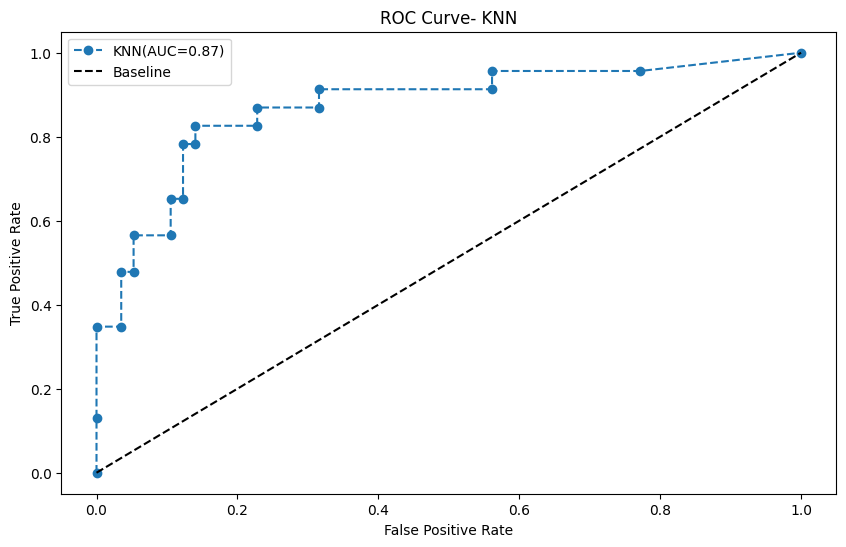

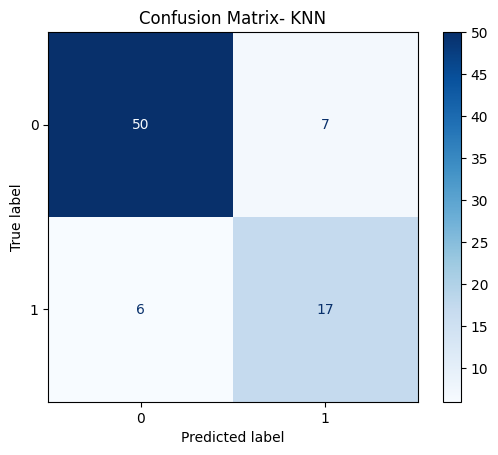

Accuracy            0.8375
ROC_AUC           0.808162
F1                0.723404
Precision         0.708333
Recall             0.73913
Fit Time     10.49 seconds
Name: GridSearch KNN, dtype: object


In [22]:
import time
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,f1_score, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve
)

knn_params= {
    'knn__n_neighbors': list (range(1,10)),
    'knn__p': [1,2,3],
    'knn__weights': ['uniform', 'distance']
}
knn_pipe= Pipeline([
    ('columns', column_transformer),
    ('knn', KNeighborsClassifier())
])

knn_grid= GridSearchCV(
    knn_pipe,
    param_grid=knn_params,
    scoring='roc_auc',
    cv=5
)
start= time.time()
knn_grid.fit(X_train, y_train)
stop= time.time()

fit_time= str(round(stop-start,2)) + ' seconds'

print(f"Best Parameters: {knn_grid.best_params_}")
print(f"Best Score: {knn_grid.best_score_}")

y_pred= knn_grid.predict(X_test)
y_probs= knn_grid.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, zero_division=0))

knn_roc_score= roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score for KNN= {knn_roc_score}")

fpr,tpr,thresholds = roc_curve(y_test, y_probs)
print('False Positive Rates:', fpr[:5])
print('True Positive Rates:', tpr[:5])

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr,'--o', label= f"KNN(AUC={knn_roc_score:.2f})")
plt.plot([0,1],[0,1], 'k--', label='Baseline')
plt.legend()
plt.title('ROC Curve- KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix- KNN')
plt.show()

results_df.loc['GridSearch KNN', 'Fit Time'] = fit_time
results_df.loc['GridSearch KNN', 'Accuracy'] = accuracy_score(y_test, y_pred)
results_df.loc['GridSearch KNN', 'ROC_AUC'] = roc_auc_score(y_test, y_pred)
results_df.loc['GridSearch KNN', 'F1'] = f1_score(y_test, y_pred)
results_df.loc['GridSearch KNN', 'Precision'] = precision_score(y_test, y_pred,zero_division=0)
results_df.loc['GridSearch KNN', 'Recall'] = recall_score(y_test, y_pred)

print(results_df.loc['GridSearch KNN'])

**SVM & GRIDSEARCH**

Best Parameters for SVC: {'svc__C': 100, 'svc__degree': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best Score for SVC: 0.8806630505410062
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        57
           1       0.79      0.83      0.81        23

    accuracy                           0.89        80
   macro avg       0.86      0.87      0.86        80
weighted avg       0.89      0.89      0.89        80

ROC AUC Score for SVM= 0.8977879481311976
False Positive Rates: [0.         0.         0.01754386 0.01754386 0.03508772]
True Positive Rates: [0.         0.04347826 0.04347826 0.43478261 0.43478261]


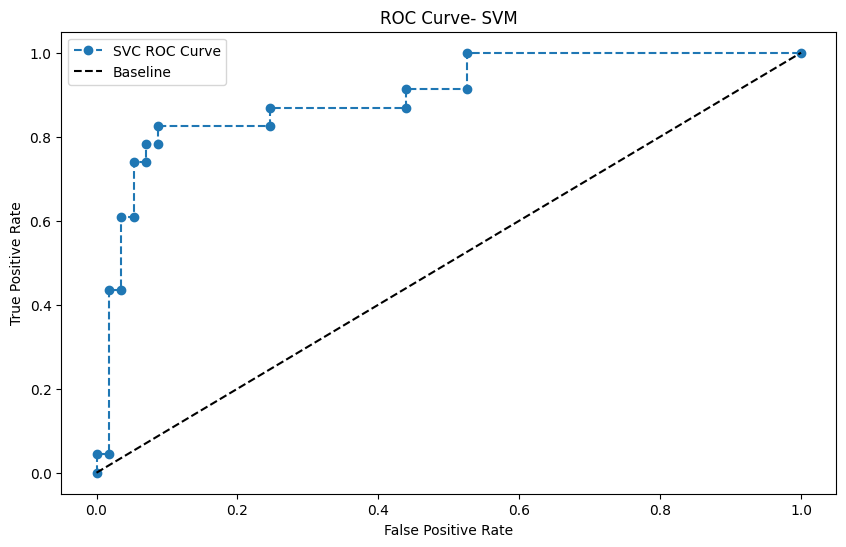

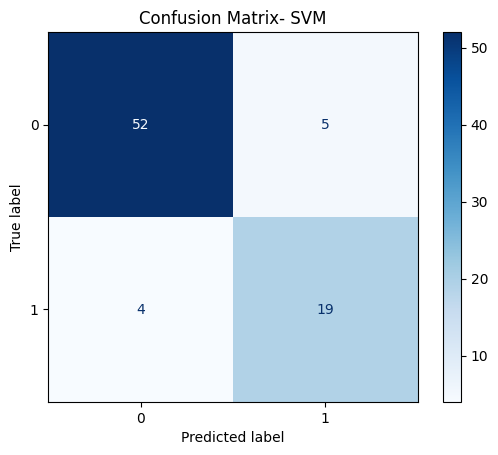

Accuracy            0.8875
ROC_AUC           0.897788
F1                0.808511
Precision         0.791667
Recall            0.826087
Fit Time     46.71 seconds
Name: GridSearch SVM, dtype: object


In [23]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, # Corrected: 'Classification_report' to 'classification_report'
    accuracy_score,
    roc_auc_score,
    f1_score,precision_score, recall_score, ConfusionMatrixDisplay, roc_curve
)

# Define the SVM pipeline
svm_pipe = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('svc', SVC(random_state=42, probability=True)) # Added probability=True for roc_auc_score and random_state
])

# Corrected svm_params dictionary
svm_params= {
    'svc__kernel':['poly','rbf', 'sigmoid'], # Corrected: added closing quote to 'sigmoid'
    'svc__degree': [1,2,3],
    'svc__gamma':[ 1,0.1,0.01,0.001],
    'svc__C': [0.1,1,10,100] # Corrected: 'svc,C' to 'svc__C'
}

svc_grid= GridSearchCV(
    svm_pipe,
    param_grid=svm_params,
    cv=5,
    scoring='roc_auc'
)
start=time.time()
svc_grid.fit(X_train, y_train) # Corrected: Use X_train, y_train for fitting
stop= time.time()

fit_time= str(round(stop-start,2)) + ' seconds'

print(f"Best Parameters for SVC: {svc_grid.best_params_}")
print(f"Best Score for SVC: {svc_grid.best_score_}")

y_pred_svm= svc_grid.predict(X_test) # Corrected: Use X_test for prediction
y_proba_svm= svc_grid.predict_proba(X_test)[:,1] # Corrected: Use X_test for proba prediction

print(classification_report(y_test, y_pred_svm)) # Corrected: Use y_test

svc_roc_score= roc_auc_score(y_test, y_proba_svm) # Corrected: Use y_test
print(f"ROC AUC Score for SVM= {svc_roc_score}")

#ROC curve

fpr,tpr,thresholds = roc_curve(y_test, y_proba_svm) # Corrected: Use y_test

print('False Positive Rates:', fpr[:5])
print('True Positive Rates:', tpr[:5])

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, '--o',label='SVC ROC Curve')
plt.plot([0,1],[0,1], 'k--', label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- SVM')
plt.legend()
plt.show()

#Confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, cmap='Blues') # Corrected: Use y_test
plt.title('Confusion Matrix- SVM')
plt.show()

# Ensure results_df is properly initialized if not already done in the current scope
if 'GridSearch SVM' not in results_df.index:
    results_df.loc['GridSearch SVM', :] = None

results_df.loc['GridSearch SVM', 'Fit Time'] = fit_time
results_df.loc['GridSearch SVM', 'Accuracy'] = accuracy_score(y_test, y_pred_svm) # Corrected: Use y_test
results_df.loc['GridSearch SVM', 'ROC_AUC'] = roc_auc_score(y_test, y_proba_svm) # Corrected: Assign actual score
results_df.loc['GridSearch SVM', 'F1'] = f1_score(y_test, y_pred_svm) # Corrected: Use y_test and y_pred_svm
results_df.loc['GridSearch SVM', 'Precision'] = precision_score(y_test, y_pred_svm,zero_division=0) # Corrected: Use y_test
results_df.loc['GridSearch SVM', 'Recall'] = recall_score(y_test,y_pred_svm) # Corrected: Use y_test and y_pred_svm


print(results_df.loc['GridSearch SVM']) # Corrected: 'SVC' to 'GridSearch SVM'

The Classification report shows strong performance for class 0 (precision 0.93, recall 0.91, f1-score 0.92) and good performance for class 1 (precision 0.79, recall 0.83, f1-score 0.81). The ROC curve and Confusion Matrix plots have also been generated to visualize these results.

**DECISION TREES &** **GRIDSEARCH**

Best Parameters: {'dtree__class_weight': None, 'dtree__criterion': 'entropy', 'dtree__max_depth': 9, 'dtree__min_samples_leaf': 10, 'dtree__min_samples_split': 2}
Best CV ROC_AUC Score: 0.8873749187784276
Fit Time 348.2 seconds
              precision    recall  f1-score   support

           0       0.87      0.82      0.85        57
           1       0.62      0.70      0.65        23

    accuracy                           0.79        80
   macro avg       0.74      0.76      0.75        80
weighted avg       0.80      0.79      0.79        80

ROC AUC Score for Decision Tree: 0.826086956521739


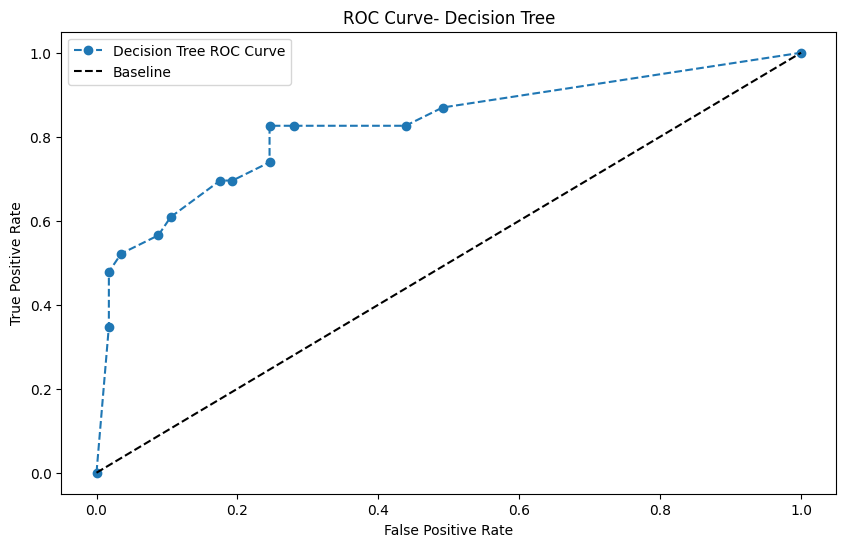

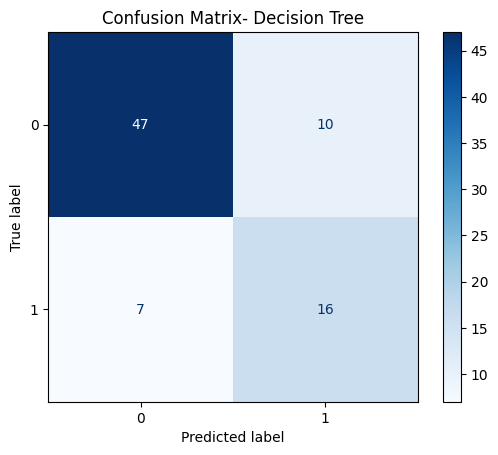

Accuracy            0.7875
ROC_AUC           0.826087
F1                0.653061
Precision         0.615385
Recall            0.695652
Fit Time     348.2 seconds
Name: GridSearch Decision Tree, dtype: object


In [31]:
import time

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve
)

dtree_params ={
    'dtree__max_depth': list(range(1,11,2)),
    'dtree__min_samples_split': list(range(2,11)),
    'dtree__criterion': ['gini','entropy'],
    'dtree__class_weight': [None, 'balanced'], # Added comma here
    'dtree__min_samples_leaf': list(range(2,21,2))
}

dtree_pipe= Pipeline([
    ('columns', column_transformer),
    ('dtree', DecisionTreeClassifier(
        class_weight= 'balanced',
        random_state=42 # Added comma here
    ))
])

dtree_grid= GridSearchCV(
    dtree_pipe,
    param_grid=dtree_params,
    scoring='roc_auc',
    cv=5)

start= time.time()
dtree_grid.fit(X_train, y_train)
stop= time.time()

fit_time= str(round(stop-start,2)) + ' seconds'

print("Best Parameters:", dtree_grid.best_params_)
print("Best CV ROC_AUC Score:", dtree_grid.best_score_)
print("Fit Time", fit_time)

#Predictions
y_pred = dtree_grid.predict(X_test)
y_pred_probs = dtree_grid.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

dtree_roc_score = roc_auc_score(y_test, y_pred_probs)

print(f"ROC AUC Score for Decision Tree: {dtree_roc_score}")

#ROC curve

fpr,tpr,thresholds = roc_curve(y_test, y_pred_probs)
plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, '--o',label='Decision Tree ROC Curve')
plt.plot([0,1],[0,1], 'k--', label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- Decision Tree')
plt.legend()
plt.show()

# Confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix- Decision Tree')
plt.show()

#save results

results_df.loc['GridSearch Decision Tree', 'Fit Time'] = fit_time
results_df.loc['GridSearch Decision Tree', 'Accuracy'] = accuracy_score(y_test, y_pred)
results_df.loc['GridSearch Decision Tree', 'ROC_AUC'] = dtree_roc_score
results_df.loc['GridSearch Decision Tree', 'F1'] = f1_score(y_test, y_pred)
results_df.loc['GridSearch Decision Tree', 'Precision'] = precision_score(y_test, y_pred, zero_division=0) # Changed zero_division=2 to zero_division=0
results_df.loc['GridSearch Decision Tree', 'Recall'] = recall_score(y_test, y_pred)

print(results_df.loc['GridSearch Decision Tree'])


**RANDOM FOREST AND GRIDSEARCH**

Best Parameters for Random Forest: {'rf__max_depth': 5, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV ROC_AUC Score: 0.9236325112297653
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        57
           1       0.75      0.78      0.77        23

    accuracy                           0.86        80
   macro avg       0.83      0.84      0.83        80
weighted avg       0.86      0.86      0.86        80

ROC AUC Score for Random Forest= 0.916094584286804


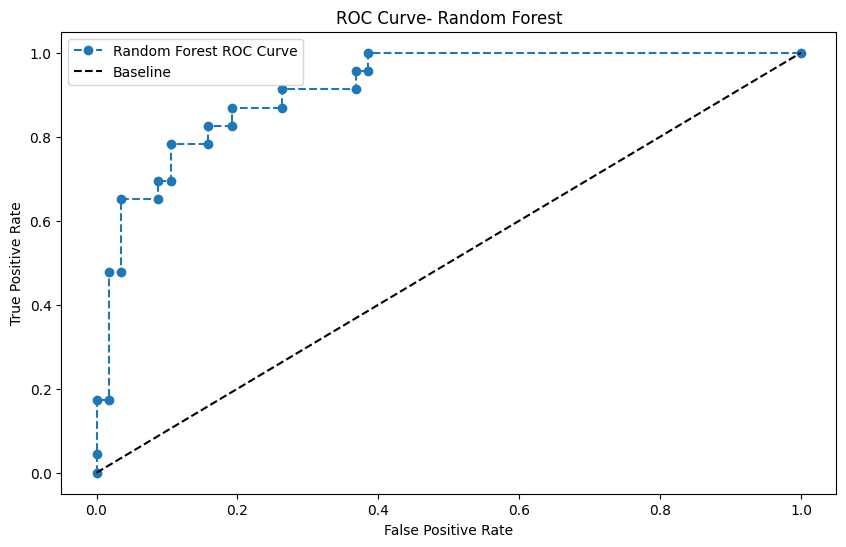

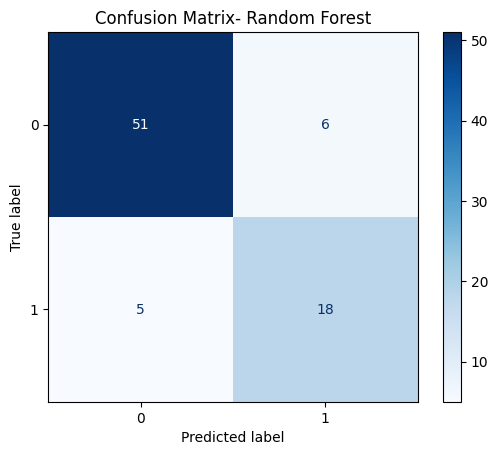

Accuracy             0.8625
ROC_AUC            0.916095
F1                 0.765957
Precision              0.75
Recall             0.782609
Fit Time     417.01 seconds
Name: GridSearch Random Forest, dtype: object


In [27]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
    roc_curve
)

# Using the globally defined X_train, y_train, X_test, y_test

#Parameters

rf_params={
    'rf__n_estimators': [100,200,300],
    'rf__max_depth': [None, 3,5,10],
    'rf__min_samples_split': [2,5,10],
    'rf__min_samples_leaf': [1,2,4],
    'rf__max_features': ['sqrt', 'log2'] # Corrected parameter name
}
#Pipeline

rf_pipe= Pipeline([
    ('columns', column_transformer),
    ('rf', RandomForestClassifier(
    class_weight='balanced',
    random_state=42))
])
# Grid Search

rf_grid= GridSearchCV(
    rf_pipe,
    param_grid=rf_params,
    cv=5,
    scoring='roc_auc' # Added scoring for GridSearchCV
)

#Fit model

start= time.time()
rf_grid.fit(X_train, y_train) # Using global X_train, y_train
stop= time.time()

fit_time= str(round(stop-start,2)) + ' seconds'

print(f"Best Parameters for Random Forest: {rf_grid.best_params_}")
print(f"Best CV ROC_AUC Score: {rf_grid.best_score_}")

#Predict

y_pred= rf_grid.predict(X_test) # Using global X_test
y_pred_probs= rf_grid.predict_proba(X_test)[:,1] # Using global X_test

#Metrics
print(classification_report(y_test, y_pred)) # Using global y_test

rf_roc_score= roc_auc_score(y_test, y_pred_probs) # Using global y_test
print(f"ROC AUC Score for Random Forest= {rf_roc_score}")

#ROC curve

fpr,tpr,thresholds = roc_curve(y_test, y_pred_probs) # Using global y_test

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, '--o',label='Random Forest ROC Curve')
plt.plot([0,1],[0,1], 'k--', label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- Random Forest')
plt.legend()
plt.show()

#Confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues') # Using global y_test

plt.title ('Confusion Matrix- Random Forest')
plt.show()

# Ensure results_df is properly initialized if not already done in the current scope
if 'GridSearch Random Forest' not in results_df.index:
    results_df.loc['GridSearch Random Forest', :] = None

results_df.loc['GridSearch Random Forest', 'Fit Time'] = fit_time
results_df.loc['GridSearch Random Forest', 'Accuracy'] = accuracy_score(y_test, y_pred)
results_df.loc['GridSearch Random Forest', 'ROC_AUC'] = rf_roc_score
results_df.loc['GridSearch Random Forest', 'F1'] = f1_score(y_test, y_pred, zero_division=0)
results_df.loc['GridSearch Random Forest', 'Precision'] = precision_score(y_test, y_pred,zero_division=0)
results_df.loc['GridSearch Random Forest', 'Recall'] = recall_score(y_test, y_pred)

print(results_df.loc['GridSearch Random Forest'])


**EXTREME GRADIENT BOOSTING & GRIDSEARCH **

Best Parameters for XGBoost: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
Best CV ROC_AUC Score: 0.9292050173743537
Fit Time: 21.82 seconds
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        57
           1       0.60      0.78      0.68        23

    accuracy                           0.79        80
   macro avg       0.75      0.79      0.76        80
weighted avg       0.81      0.79      0.79        80



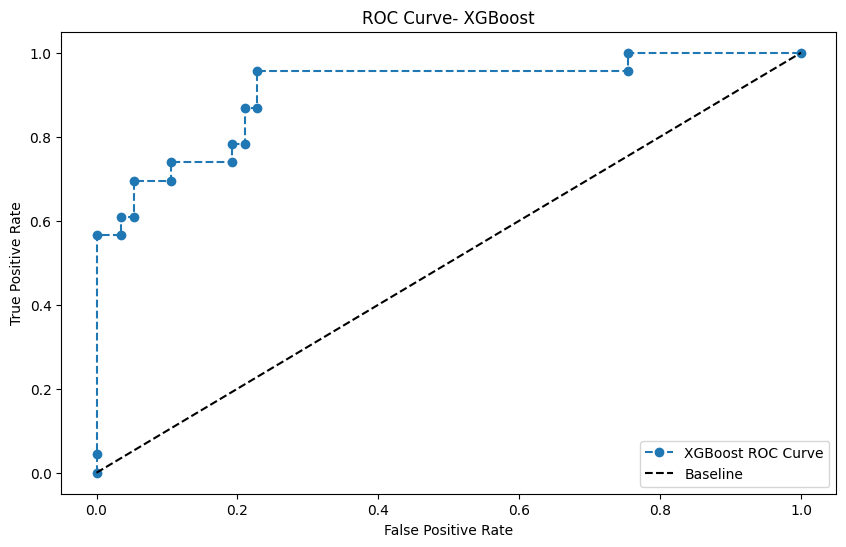

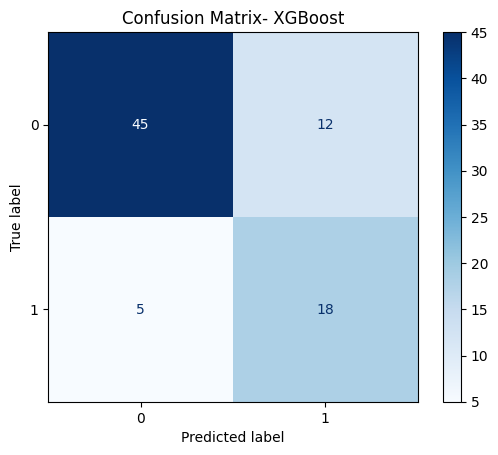

Accuracy            0.7875
ROC_AUC           0.909992
F1                0.679245
Precision              0.6
Recall            0.782609
Fit Time     21.82 seconds
Name: GridSearch XGBoost, dtype: object


In [33]:
import time
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve
)
#Calculate class balance for XGBoost
negative_count= (y_train == 0).sum()
positive_count= (y_train == 1).sum()

scale_pos_weight= negative_count / positive_count

#XGBoost parameter grid

xgb_params= {
    'xgb__n_estimators': [100,200],
    'xgb__max_depth': [3,5,7],
    'xgb__learning_rate': [0.01,0.1],
    'xgb__subsample': [0.8,1.0],
    'xgb__colsample_bytree': [0.8,1.0],

}

#Pipeline

xgb_pipe= Pipeline([
    ('columns', column_transformer),
    ('xgb', XGBClassifier(
        scale_pos_weight= scale_pos_weight,
        random_state=42,
        eval_metric ='logloss'
    ))
])

#GridSearch

xgb_grid= GridSearchCV(
    xgb_pipe,
    param_grid=xgb_params,
    scoring='roc_auc',
    cv=5
)

# Fit model and time it

start= time.time()
xgb_grid.fit(X_train, y_train)
stop=time.time()

fit_time= str(round(stop-start,2)) + ' seconds'

print(f"Best Parameters for XGBoost: {xgb_grid.best_params_}")
print(f"Best CV ROC_AUC Score: {xgb_grid.best_score_}")
print(f"Fit Time: {fit_time}")

#Predictions

y_pred = xgb_grid.predict(X_test)
y_pred_probs = xgb_grid.predict_proba(X_test)[:,1]

#Classification report

print(classification_report(y_test, y_pred))

#ROC_AUC
xgb_roc_score = roc_auc_score(y_test, y_pred_probs)
fpr,tpr,thresholds = roc_curve(y_test, y_pred_probs)

plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, '--o',label='XGBoost ROC Curve')
plt.plot([0,1],[0,1], 'k--', label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- XGBoost')
plt.legend()
plt.show()

#Confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix- XGBoost')
plt.show()

#save results

results_df.loc['GridSearch XGBoost', 'Fit Time'] = fit_time
results_df.loc['GridSearch XGBoost', 'Accuracy'] = accuracy_score(y_test, y_pred)
results_df.loc['GridSearch XGBoost', 'ROC_AUC'] = xgb_roc_score
results_df.loc['GridSearch XGBoost', 'F1'] = f1_score(y_test, y_pred)
results_df.loc['GridSearch XGBoost', 'Precision'] = precision_score(y_test, y_pred,zero_division=0)
results_df.loc['GridSearch XGBoost', 'Recall'] = recall_score(y_test, y_pred)

print(results_df.loc['GridSearch XGBoost'])

**MODEL COMPARISON**

In [34]:
results_df

,Accuracy,ROC_AUC,F1,Precision,Recall,Fit Time
Decision Tree,0.8125,0.803585,0.862385,0.903846,0.824561,NaN
GridSearch Logistic Regression,0.7625,0.781465,0.666667,0.558824,0.826087,4.04 seconds
GridSearch KNN,0.8375,0.808162,0.723404,0.708333,0.73913,10.49 seconds
GridSearch SVM,0.8875,0.897788,0.808511,0.791667,0.826087,46.71 seconds
GridSearch Random Forest,0.8625,0.916095,0.765957,0.75,0.782609,417.01 seconds
GridSearch Decision Tree,0.7875,0.826087,0.653061,0.615385,0.695652,348.2 seconds
GridSearch XGBoost,0.7875,0.909992,0.679245,0.6,0.782609,21.82 seconds


**CONCLUSION**

The purpose of this study is to develop and evaluate predictive models to identify patients with MGUS and Smoldering multiple myeloma who are at increased risk of progressing to multiple myeloma.
This study aims to determine whether clinical and laboratory features can predict progression from MGUS or SMM to active multiple myeloma using supervised machine learning models.
My most important metric is recall for class 1 in the clinical setting, because we want to avoid missing patients who truly progress. The ROC_AUC is also very useful because it shows how well the model ranks high risk versus low-risk patients.
I also would like to take one step further, the next high impact improvement would be: tuning the decision threshold ( not just 0.5) and/or comparing models specifically on recall vs precision tradeoffs.